# 🔎 Análise de curvas de luz em Raios-X (EPIC-pn)

Réplica do pipeline de dados reais de `main-uv-lightcurves.ipynb` (curvas de luz em UVM2 via XMM-Newton/OM), agora usando o **EPIC-pn** do mesmo XMM-Newton, na mesma observação, para os mesmos 10 trânsitos de HD 189733 A/b.

## Por quê raios-X

EUV puro (tipo o canal 171 Å do AIA, que já usamos como referência solar) não é observável em outras estrelas além de algumas dezenas de parsecs — o meio interestelar absorve quase toda a emissão EUV. Por isso a literatura de CMEs estelares usa **dimming em raios-X mole** como substituto direto, com detecções já publicadas (Proxima Centauri, AB Doradus, ε Eridani — Veronig et al. 2021, *Nature Astronomy*; revisão em Loyd et al. 2025, ApJ). A lógica física é a mesma do 171 Å: ambos traçam plasma coronal quente, e o mecanismo de dimming (perda de massa/densidade na erupção) é o mesmo.

**Não estamos restritos a procurar só dimming.** Qualquer assinatura de CME é candidata: dimming (perda de plasma), brilho excedente de um flare/arco associado à erupção, ou o momento em que a estrutura se desprende da estrela. Por isso escolhemos o instrumento com melhor estatística e resolução temporal, não otimizado só pra um tipo de sinal.

## Por que EPIC-pn (e não MOS1/MOS2)

As 3 câmeras do EPIC (MOS1, MOS2, pn) têm produtos de curva de luz já processados e prontos (`SRCTSR`, fundo já subtraído) nas mesmas pastas `pps/` onde já estão os dados de OM — não precisou baixar nada novo. Comparando os produtos "banda cheia" (0.2–12 keV) de cada instrumento pra observação 0506070201:

| Instrumento | Cadência nativa | Taxa média | Pontos |
|---|---|---|---|
| MOS1 | 100 s (fixo) | ~0.05 cts/s | 546 |
| MOS2 | 100 s (fixo) | ~0.05 cts/s | ~530 |
| **pn** | **0.12–1.46 s (varia por obs)** | **~0.25–0.36 cts/s** | **25 mil a 450 mil** |

O pn tem ~5x mais contagem total que um único MOS, e resolução temporal nativa muito mais fina — importante se o sinal for algo impulsivo (flare/arco) e não só um dimming gradual e lento. MOS1/MOS2 já vêm pré-binados em 100s fixos, o que já "borra" qualquer coisa mais rápida que isso antes mesmo de olharmos os dados.

**Caminho natural de expansão (não feito aqui):** somar MOS1+MOS2+pn pra estatística ainda melhor. Não implementado nesta primeira versão — pn sozinho já é a melhor fonte única de sinal.

## Fonte dos dados

Mesmas pastas `pps/` de cada observação já usadas em `main-uv-lightcurves.ipynb` (`.../HD189733/ligthcurves-om/<OBS_ID>/pps/`). Arquivo usado por observação: `P<OBS_ID>PNS<exp>SRCTSR8001.FTZ` — banda cheia (0.2–12 keV), fundo já subtraído (`HDUCLAS2=NET`), mesmas colunas `TIME`/`RATE`/`ERROR` do produto `TIMESR` do OM.

## Limitações conhecidas (honestas, não resolvidas aqui)

1. **Coeficientes de limb darkening**: reaproveitamos os mesmos valores usados no modelo em UV (`u1`, `u2`). Fisicamente questionável para raios-X — a coroa estelar não segue o mesmo perfil de escurecimento de limbo do contínuo óptico/UV (pode até ser *brightening* de limbo, dependendo da estrutura coronal). Mantido como simplificação de partida, não como afirmação física validada.
2. **Alinhamento temporal entre instrumentos**: os valores de `tC` (centro do trânsito, em horas desde o início do arquivo) foram calibrados originalmente a partir dos dados de OM. Aqui assumimos que o pn começa a expor em torno do mesmo instante absoluto que o OM — se o trânsito aparecer deslocado no gráfico, esse é o primeiro lugar a investigar (recalibrar `tC` usando o `TSTART` absoluto de cada instrumento, em vez de "horas desde o primeiro arquivo do glob").

## Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('01-Core/'))


In [2]:
from astropy.time import Time
from astropy.time import TimeDelta
import numpy as np

from Star.Estrela import Estrela, GeometriaCME
from Planet.Eclipse import Eclipse
from Planet.Planeta import Planeta
import matplotlib.pyplot as plt
import os
import glob
from astropy.io import fits


## Funções base

`calcular_transito`, `modelo_de_transito_eclipse` e `bin_data` são idênticas às de `main-uv-lightcurves.ipynb` — a órbita e o modelo geométrico do ECLIPSE não dependem do comprimento de onda observado. Só `busca_fluxo_normalizado` muda de verdade: agora lê `RATE`/`ERROR` de produtos `SRCTSR` do EPIC-pn em vez de `TIMESR` do OM (mesmos nomes de coluna, então a lógica interna é a mesma).

In [3]:
def calcular_transito(data_alvo_str, T0=2454279.436593, P=2.21857520, duracao_horas=1.8):
    """
    Calcula os tempos de inicio, meio e fim de um transito de HD 189733b
    proximo a uma data alvo, usando uma efemeride de alta precisao.
    """
    t_alvo = Time(data_alvo_str, format='iso', scale='utc')
    n_orbita = np.round((t_alvo.jd - T0) / P)
    jd_meio_transito = T0 + (n_orbita * P)
    t_meio_transito = Time(jd_meio_transito, format='jd', scale='tdb')

    metade_duracao_segundos = (duracao_horas / 2.0) * 3600.0
    metade_duracao = TimeDelta(metade_duracao_segundos, format='sec')

    t_inicio_transito = t_meio_transito - metade_duracao
    t_fim_transito = t_meio_transito + metade_duracao

    return {
        'orbita_n': int(n_orbita),
        'meio_transito_utc': t_meio_transito.utc.iso,
        'inicio_transito_utc': t_inicio_transito.utc.iso,
        'fim_transito_utc': t_fim_transito.utc.iso,
        'meio_transito_jd': jd_meio_transito,
    }


In [4]:
def modelo_de_transito_eclipse(tempo_horas_alvo, parametros):
    """
    Usa o codigo ECLIPSE para gerar um modelo geometrico de transito.
    Identico ao usado em main-uv-lightcurves.ipynb: o modelo nao depende
    do comprimento de onda observado, so da geometria estrela-planeta.
    """
    raio = 373.
    intensidadeMaxima = 240
    tamanhoMatriz = 856
    u1 = parametros['u1']
    u2 = parametros['u2']

    raio_plan_Jup = parametros['raio_plan_Jup']
    semi_eixo_UA = parametros['semi_eixo_UA']
    angulo_inclinacao = parametros['angulo_inclinacao']
    periodo = parametros['periodo']
    mass_planeta = 1.138
    ecc = 0
    anomalia = 0
    rsun = parametros['rsun']

    estrela_ = Estrela(raio, rsun, intensidadeMaxima, u1, u2, tamanhoMatriz)
    Nx = estrela_.getNx()
    Ny = estrela_.getNy()
    raioEstrelaPixel = estrela_.getRaioStar()

    planeta_ = Planeta(semi_eixo_UA, raio_plan_Jup, periodo, angulo_inclinacao, ecc, anomalia, estrela_.getRaioSun(), mass_planeta)

    eclipse = Eclipse(Nx, Ny, raioEstrelaPixel, estrela_, planeta_, 1)
    eclipse.setTempoHoras(5.)
    eclipse.criarEclipse(anim=False, plot=False)

    lc0 = np.array(eclipse.getCurvaLuz())
    ts0 = np.array(eclipse.getTempoHoras())

    lc0_normalizado = lc0 / np.max(lc0)
    tempo_centro_modelo_simulado = ts0[np.argmin(lc0_normalizado)]
    ts0_alinhado = ts0 - tempo_centro_modelo_simulado + parametros['tC']

    fluxo_final_modelo = np.interp(tempo_horas_alvo, ts0_alinhado, lc0_normalizado)
    return fluxo_final_modelo


def busca_fluxo_normalizado(lista_arquivos):
    """
    Le TIME/RATE/ERROR de uma lista de arquivos SRCTSR (ou TIMESR), concatena,
    ordena por tempo e normaliza pela media do fluxo fora do transito (>3h).

    O EPIC-pn tem uma pequena fracao de bins nao-finitos (NaN) por causa de
    gaps de GTI na cadencia nativa de 0.1-1.5s (nao presente nos dados de OM,
    que tem cadencia bem mais grosseira) -- um unico NaN contaminaria toda a
    media em np.mean(), entao filtramos antes de normalizar.
    """
    todos_tempos, todos_fluxos, todos_erros = [], [], []
    for arquivo in lista_arquivos:
        with fits.open(arquivo) as hdul:
            dados = hdul[1].data
            todos_tempos.extend(dados['TIME'])
            todos_fluxos.extend(dados['RATE'])
            todos_erros.extend(dados['ERROR'])
    todos_tempos, todos_fluxos, todos_erros = np.array(todos_tempos), np.array(todos_fluxos), np.array(todos_erros)
    indices_ordenados = np.argsort(todos_tempos)
    tempos_ordenados = todos_tempos[indices_ordenados]
    fluxos_ordenados = todos_fluxos[indices_ordenados]
    erros_ordenados = todos_erros[indices_ordenados]

    finito = np.isfinite(fluxos_ordenados) & np.isfinite(erros_ordenados)
    tempos_ordenados = tempos_ordenados[finito]
    fluxos_ordenados = fluxos_ordenados[finito]

    tempos_em_horas = (tempos_ordenados - tempos_ordenados[0]) / 3600.0
    fluxos_normalizados = fluxos_ordenados / np.mean(fluxos_ordenados[tempos_em_horas > 3.0])
    return tempos_em_horas, fluxos_normalizados


def bin_data(tempos_em_horas, fluxos_normalizados, bin=0.05):
    """
    Rebina a curva de luz em bins de largura fixa (horas). Padrao 0.05h (=180s),
    mais fino que os 0.15-0.2h usados para o OM, ja que o pn tem cadencia nativa
    muito mais alta e mais contagem total para sustentar bins menores.
    """
    bin_size_horas = bin
    bins = np.arange(tempos_em_horas.min(), tempos_em_horas.max(), bin_size_horas)
    binned_time, binned_flux, binned_error = [], [], []

    for i in range(len(bins) - 1):
        mask = (tempos_em_horas >= bins[i]) & (tempos_em_horas < bins[i + 1])
        if np.sum(mask) > 0:
            binned_time.append(np.mean(tempos_em_horas[mask]))
            binned_flux.append(np.mean(fluxos_normalizados[mask]))
            n_points = len(fluxos_normalizados[mask])
            binned_error.append(np.std(fluxos_normalizados[mask]) / np.sqrt(n_points))

    return binned_time, binned_flux, binned_error


In [5]:
def plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs):
    plt.figure(figsize=(16, 8))
    plt.errorbar(binned_time, binned_flux, yerr=binned_error, fmt='o', markersize=5, color='darkred', ecolor='darkred', capsize=3, alpha=0.7, label='EPIC-pn (binado)')
    plt.plot(tempo_modelo_plot, fluxo_do_seu_modelo, color='blue', linewidth=2.5, label='Modelo ECLIPSE (geometria do transito)')
    plt.axhline(1.0, color='black', linestyle='--', alpha=0.7, label='Linha de base')
    plt.title('EPIC-pn (raios-X) para HD 189733: ' + date_obs + " ID:" + id_obs)
    plt.xlabel('Tempo (horas desde o inicio da observacao)')
    plt.ylabel('Taxa de contagem normalizada')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_residual(binned_time, residuo, date_obs, id_obs, output_dir='03-Products/xray'):
    """Plota e salva o residuo (dado binado - modelo geometrico) para uma observacao."""
    plt.figure(figsize=(16, 5))
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.plot(binned_time, residuo, 'o-', color='darkorange', markersize=4, alpha=0.8, label='Residuo (dado - modelo)')
    plt.title('Residuo EPIC-pn: ' + date_obs + " ID:" + id_obs)
    plt.xlabel('Tempo (horas desde o inicio da observacao)')
    plt.ylabel('Fluxo normalizado (dado - modelo)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    os.makedirs(output_dir, exist_ok=True)
    file_path = os.path.join(output_dir, f"residual_xray_{id_obs}.png")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    print(f"Figura salva em: {file_path}")
    plt.show()


In [6]:
padrao_arquivo = '*PNS*SRCTSR8001.FTZ'


## Definição dos parâmetros para execução do modelo

In [7]:
parametros_modelo = {
    'rsun': 0.805,
    'u1': 0.0618,
    'u2': 0.0204,
    'raio_plan_Jup': 1.138,
    'semi_eixo_UA': 0.031,
    'angulo_inclinacao': 85.710,
    'periodo': 2.21857520,
    'tC': 1,  # sera sobrescrito por observacao, mesmos valores calibrados a partir do OM
}


## As 10 observações

Mesmas pastas, datas e valores de `tC` usados em `main-uv-lightcurves.ipynb` — os dados de raios-X vivem na mesma pasta `pps/` que os de UV, e o centro do trânsito é uma propriedade orbital (não depende do instrumento).

In [8]:
observacoes = [
    {'id_obs': '0506070201', 'date_obs': "2007-04-17 14:06:31 a 2007-04-18 05:20:49", 'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/', 'tC': 9.5161, 'label': '2007-04-17'},
    {'id_obs': '0690890201', 'date_obs': "2012-06-07 18:24:32 a 2012-06-08 11:29:48", 'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0690890201/pps/', 'tC': 7.4245, 'label': '2012-06-07'},
    {'id_obs': '0672390201', 'date_obs': "2011-04-30 23:14:20 a 2011-05-01 10:06:12", 'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0672390201/pps/', 'tC': 7.8336, 'label': '2011-05-01'},
    {'id_obs': '0744981401', 'date_obs': "2014-11-13 06:46:05 a 2014-11-13 15:39:25", 'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981401/pps/', 'tC': 5.2427, 'label': '2014-11-13'},
    {'id_obs': '0744981601', 'date_obs': "2015-04-17 12:34:55 a 2015-04-17 23:58:15", 'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981601/pps/', 'tC': 6.8033, 'label': '2015-04-17'},
    {'id_obs': '0744981701', 'date_obs': "2015-04-19 19:06:26 a 2015-04-20 05:39:46", 'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981701/pps/', 'tC': 4.5239, 'label': '2015-04-19'},
    {'id_obs': '0744980801', 'date_obs': "2014-10-17 16:08:26 a 2014-10-18 02:25:06", 'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744980801/pps/', 'tC': 4.695, 'label': '2014-10-1'},
    {'id_obs': '0744981201', 'date_obs': "2014-11-11 00:37:26 a 2014-11-11 12:50:46", 'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981201/pps/', 'tC': 6.1414, 'label': '2014-11-11'},
    {'id_obs': '0744980601', 'date_obs': "2014-05-17 14:21:12 a 2014-05-17 23:14:32", 'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744980601/pps/', 'tC': 4.8147, 'label': '2014-05-17'},
    {'id_obs': '0744980701', 'date_obs': "2014-11-15 09:48:00 a 2014-11-15 20:38:00", 'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744980701/pps/', 'tC': 7.4447, 'label': '2014-11-15'},
]


## Carregando, plotando e calculando o resíduo — por observação

Para cada observação: busca o arquivo `SRCTSR8001` do EPIC-pn, monta a curva de luz normalizada, compara com o modelo geométrico de trânsito (sem CME), plota, e salva o resíduo (dado − modelo) — é nesse resíduo que uma assinatura de CME (dimming, excesso de brilho, etc.) apareceria, do mesmo jeito que apareceu nos dados de UVM2 para Obs 03 e Obs 06.


=== 2007-04-17 (ID 0506070201) ===


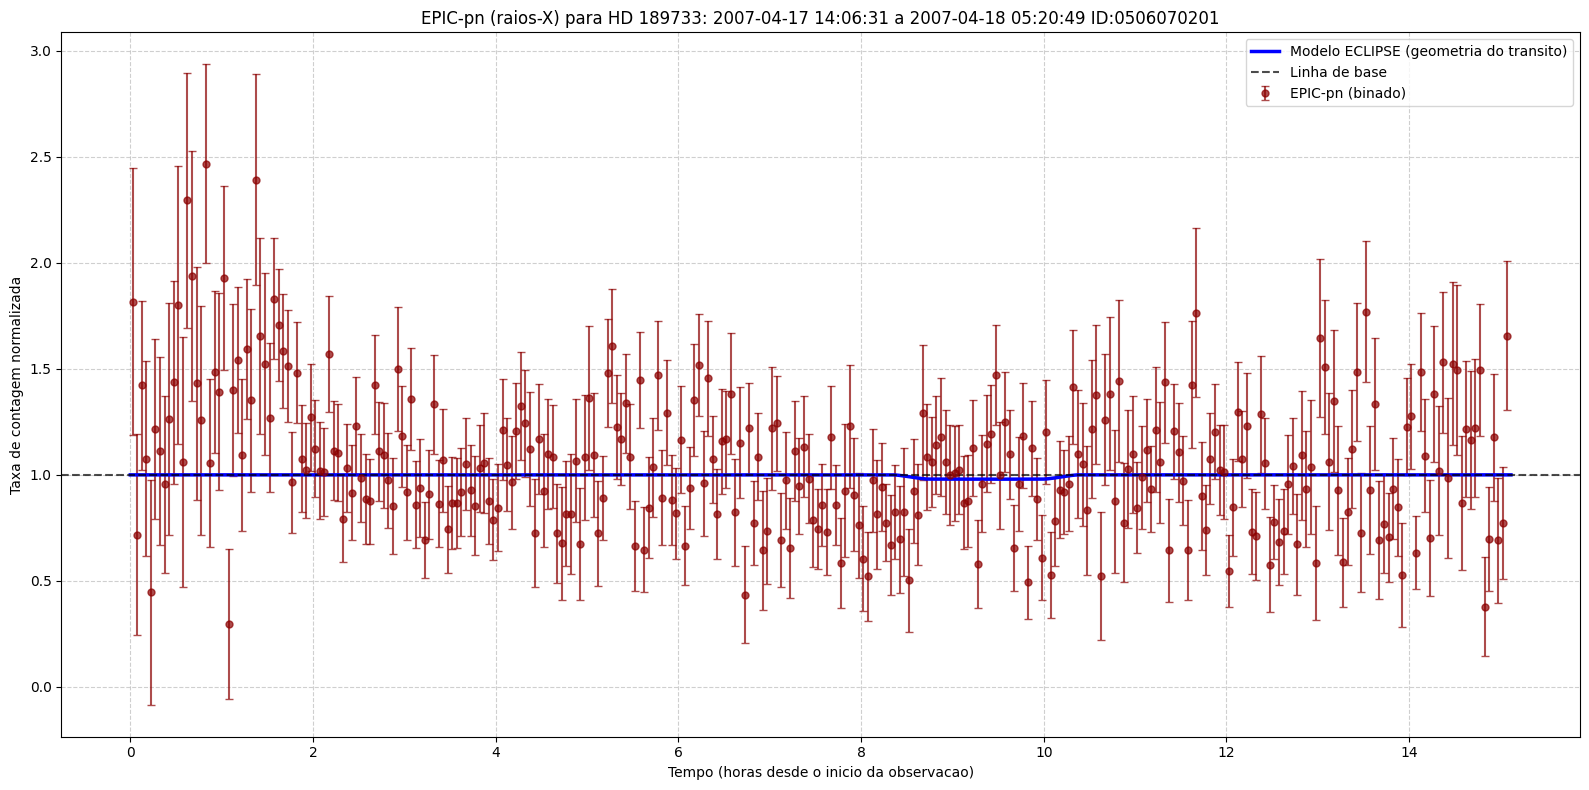

Figura salva em: 03-Products/xray/residual_xray_0506070201.png


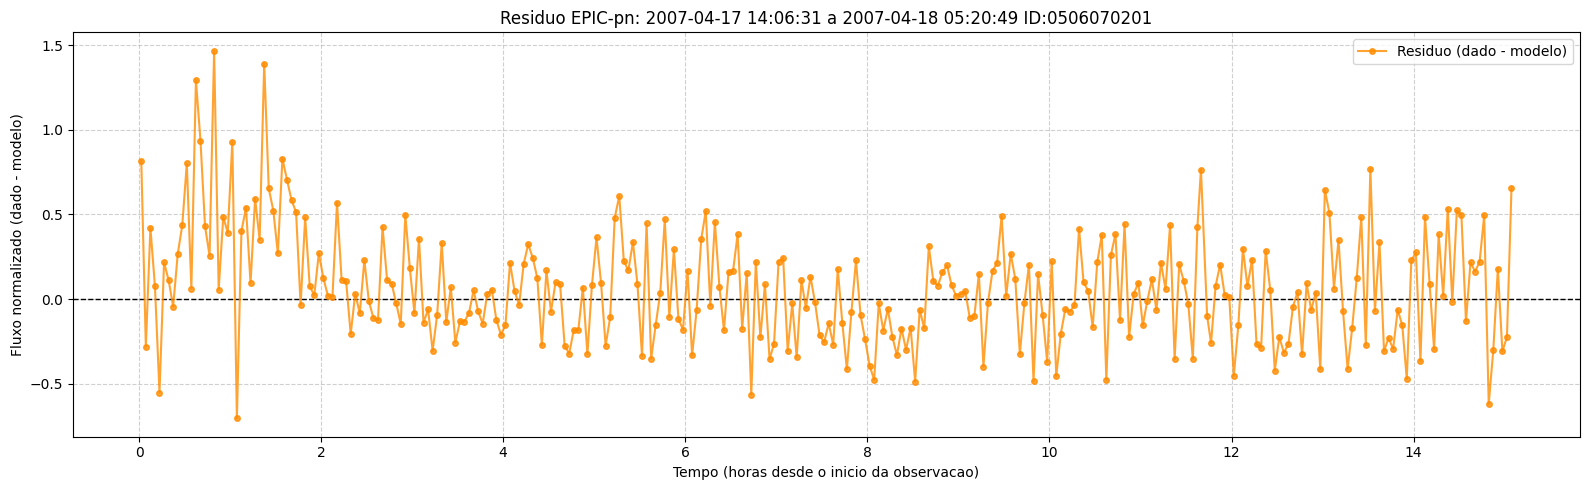


=== 2012-06-07 (ID 0690890201) ===


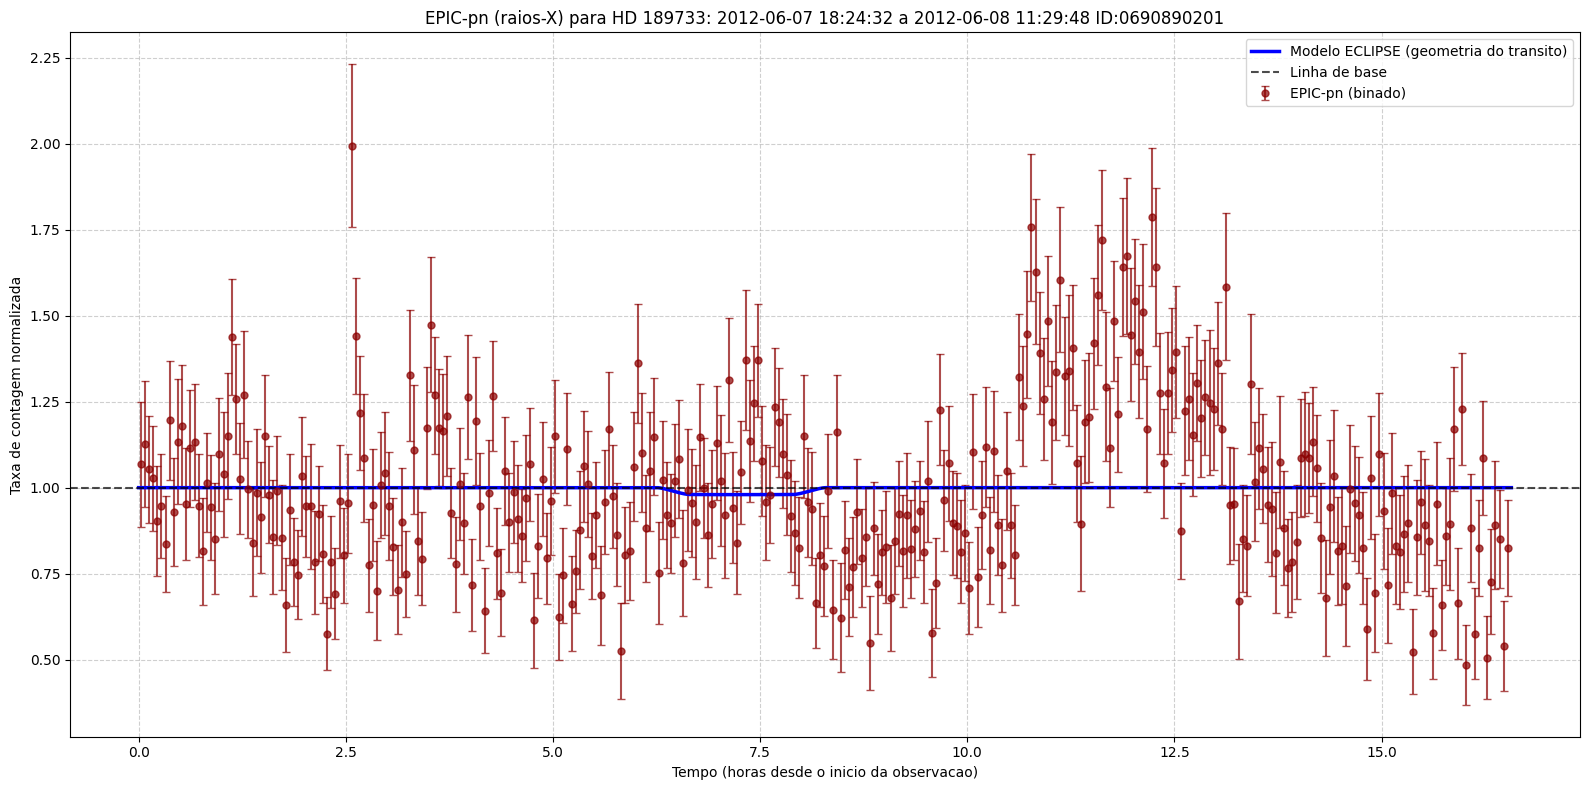

Figura salva em: 03-Products/xray/residual_xray_0690890201.png


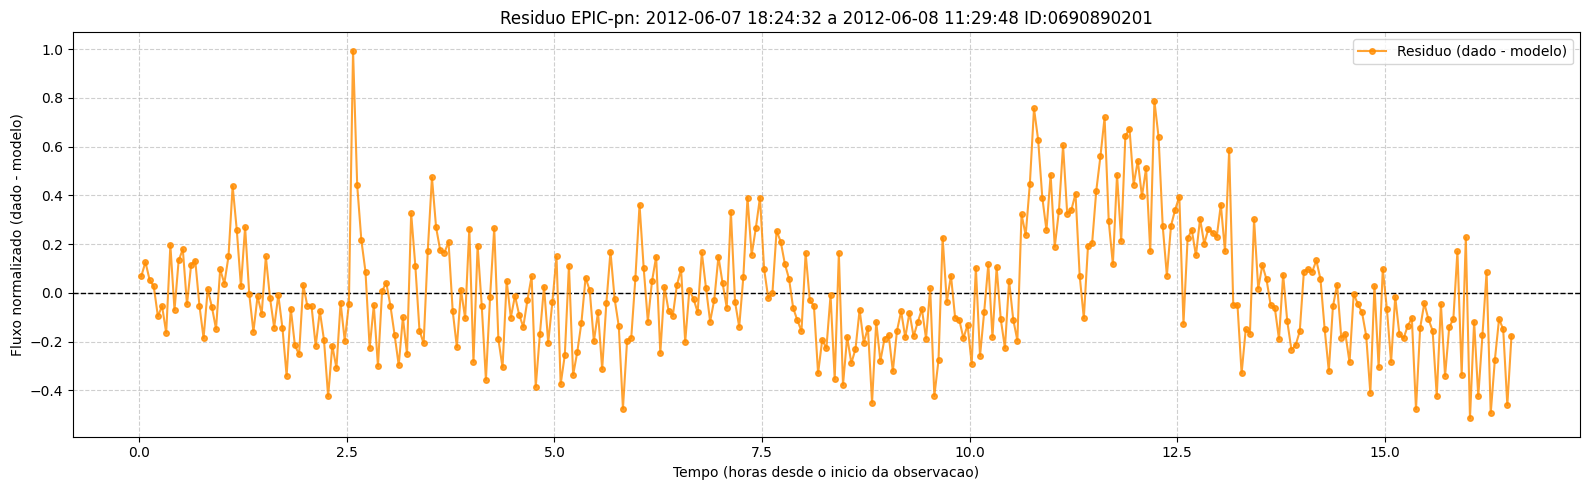


=== 2011-05-01 (ID 0672390201) ===


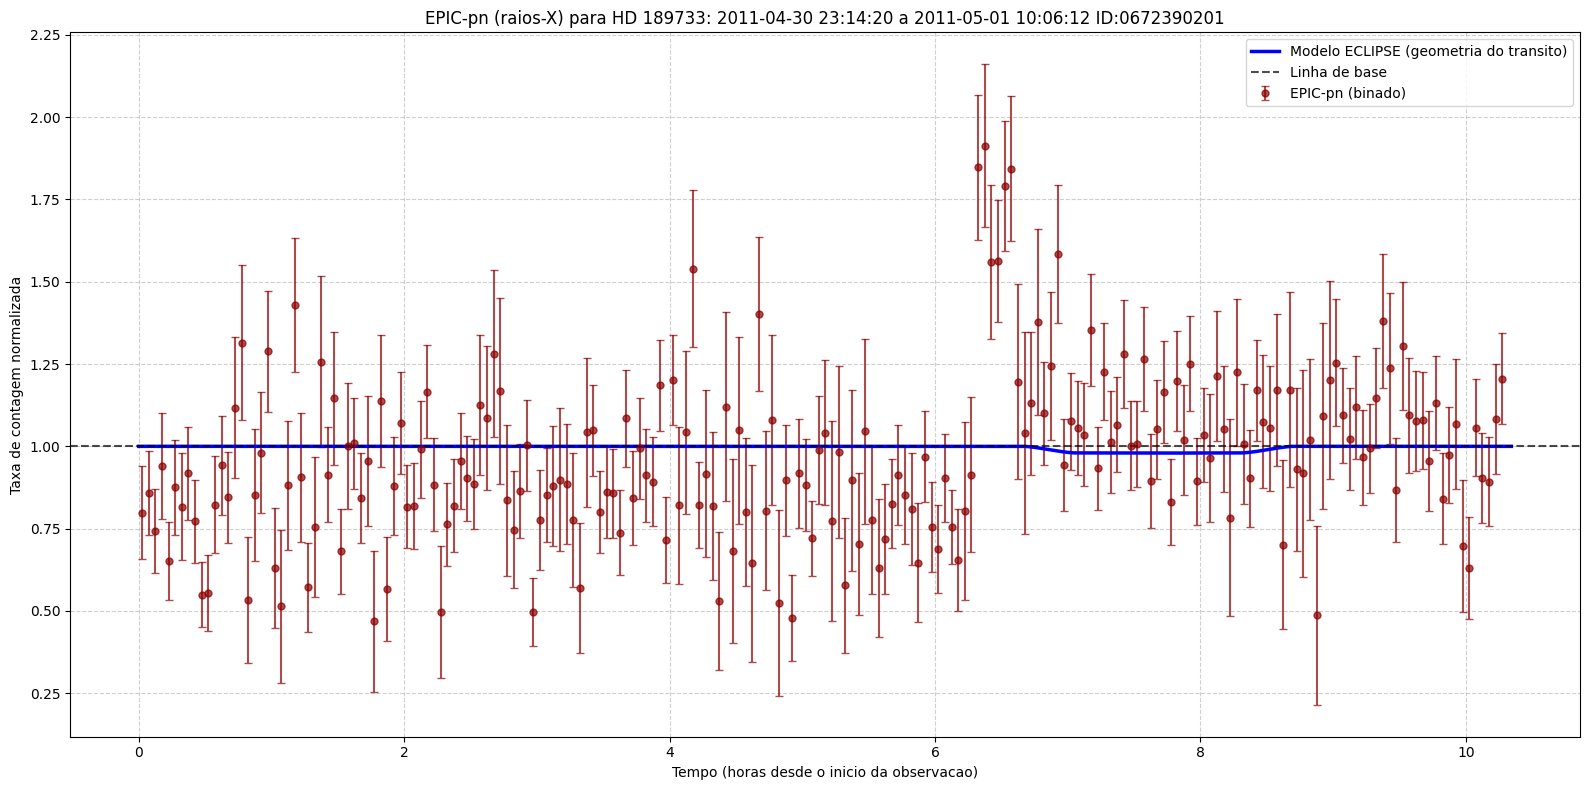

Figura salva em: 03-Products/xray/residual_xray_0672390201.png


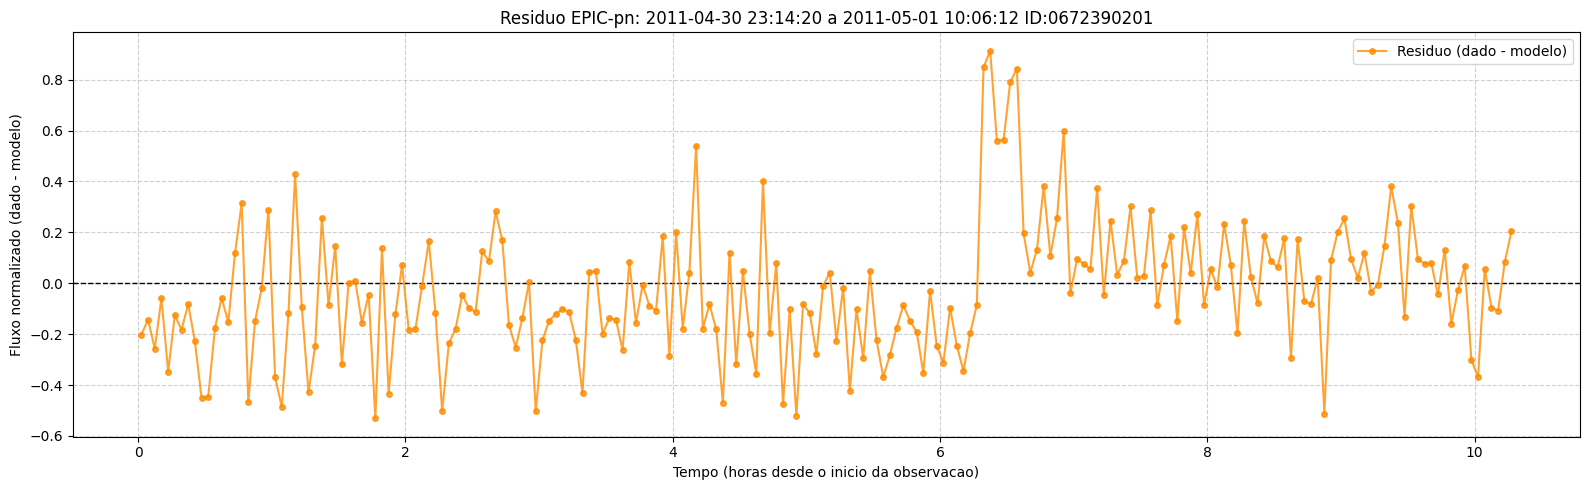


=== 2014-11-13 (ID 0744981401) ===


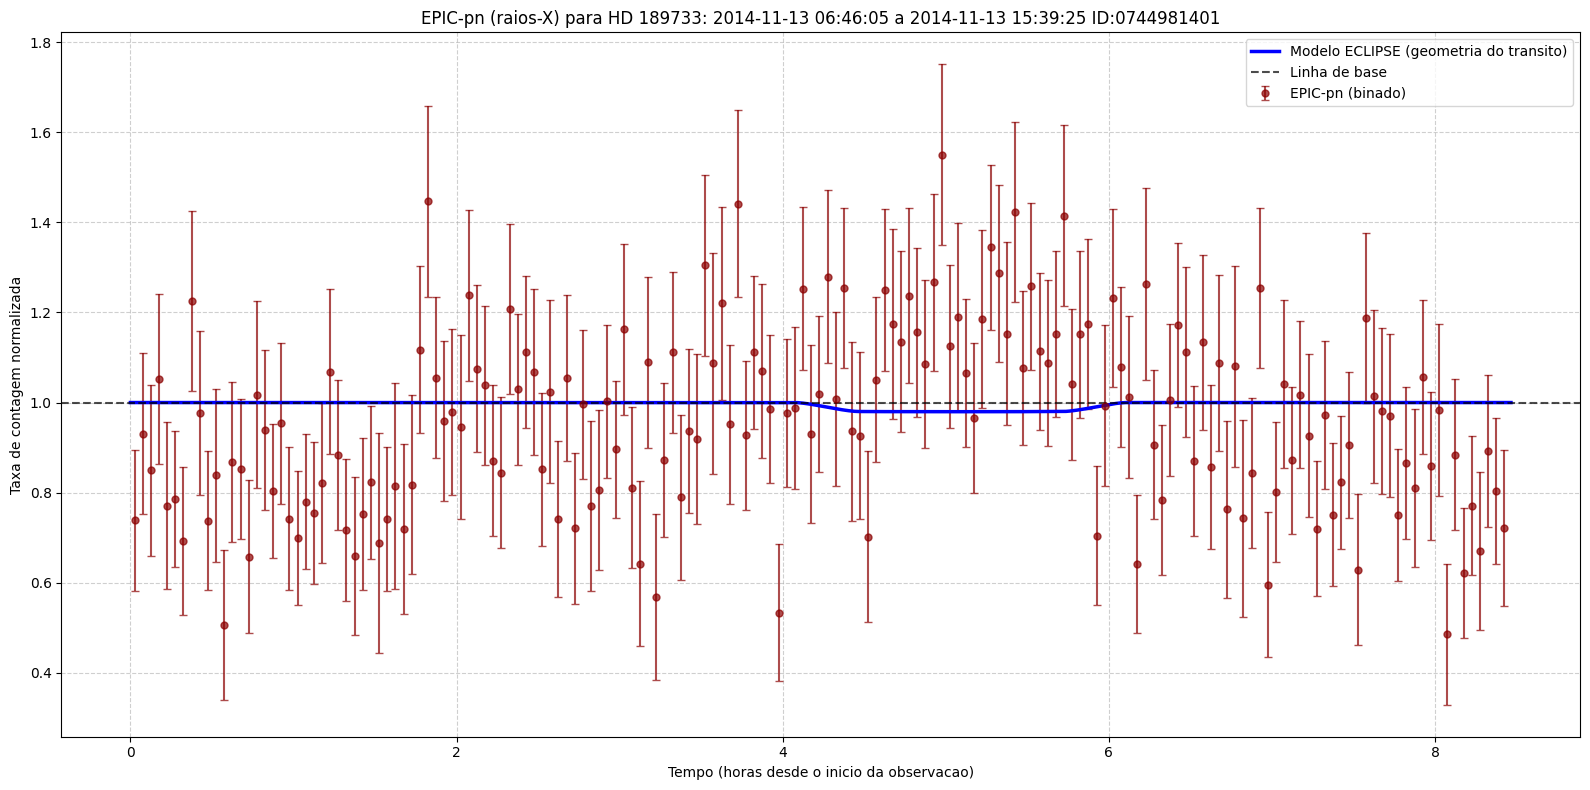

Figura salva em: 03-Products/xray/residual_xray_0744981401.png


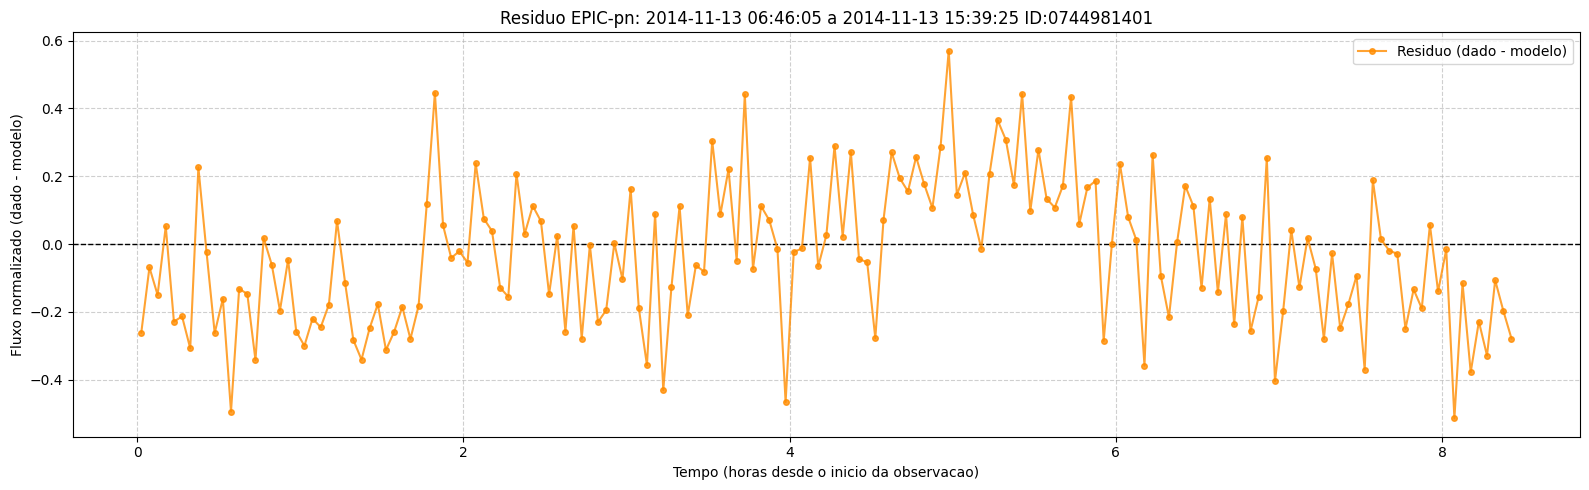


=== 2015-04-17 (ID 0744981601) ===


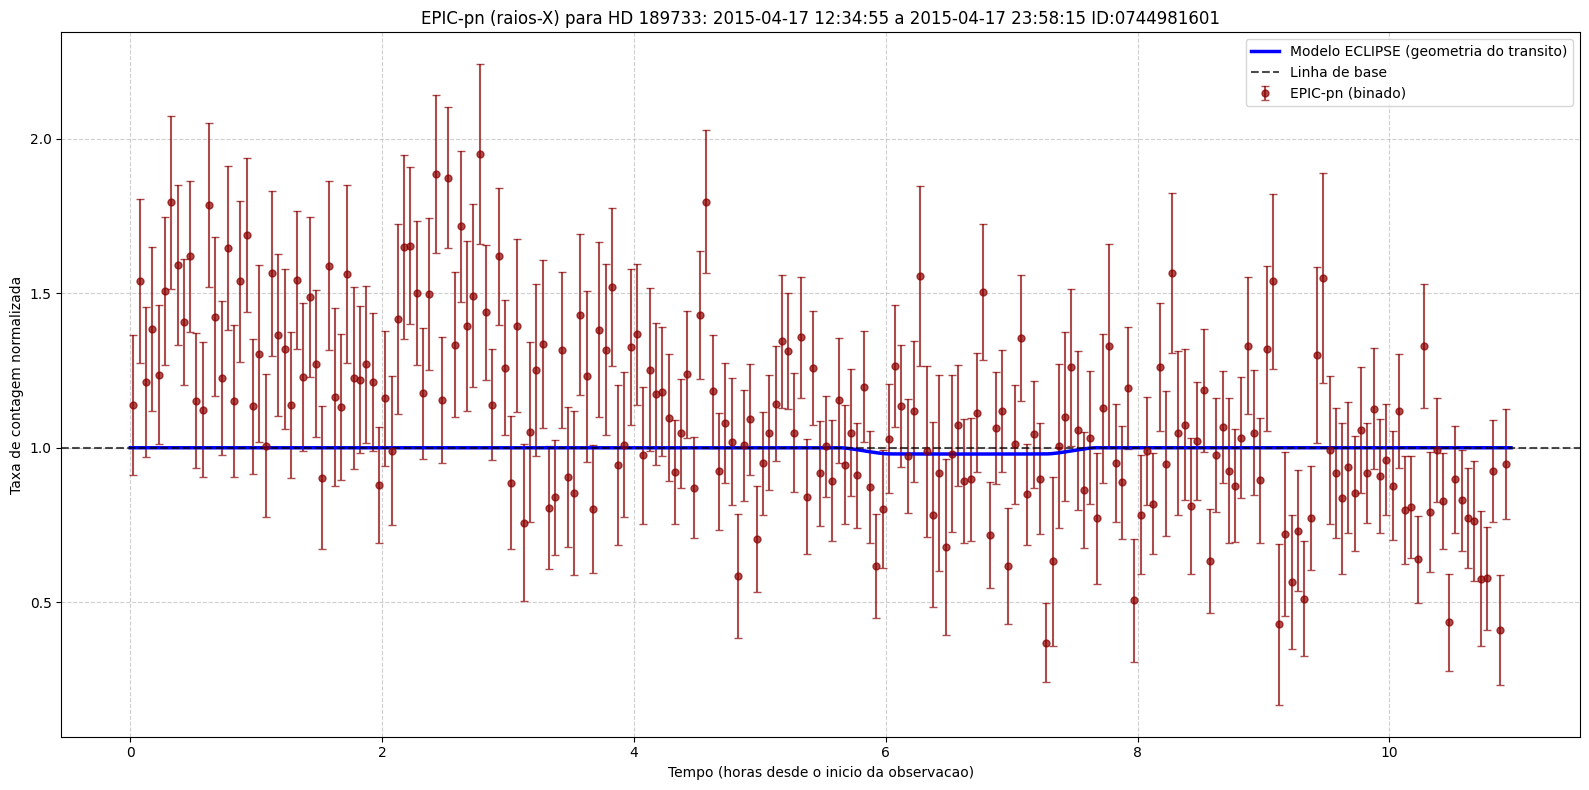

Figura salva em: 03-Products/xray/residual_xray_0744981601.png


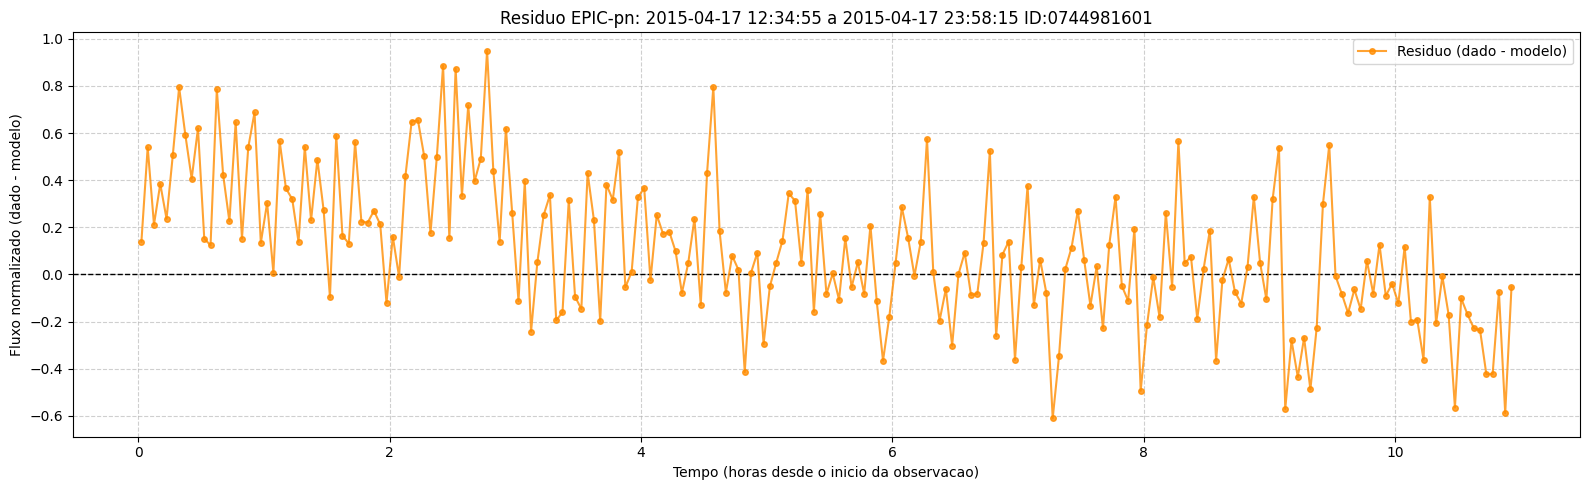


=== 2015-04-19 (ID 0744981701) ===


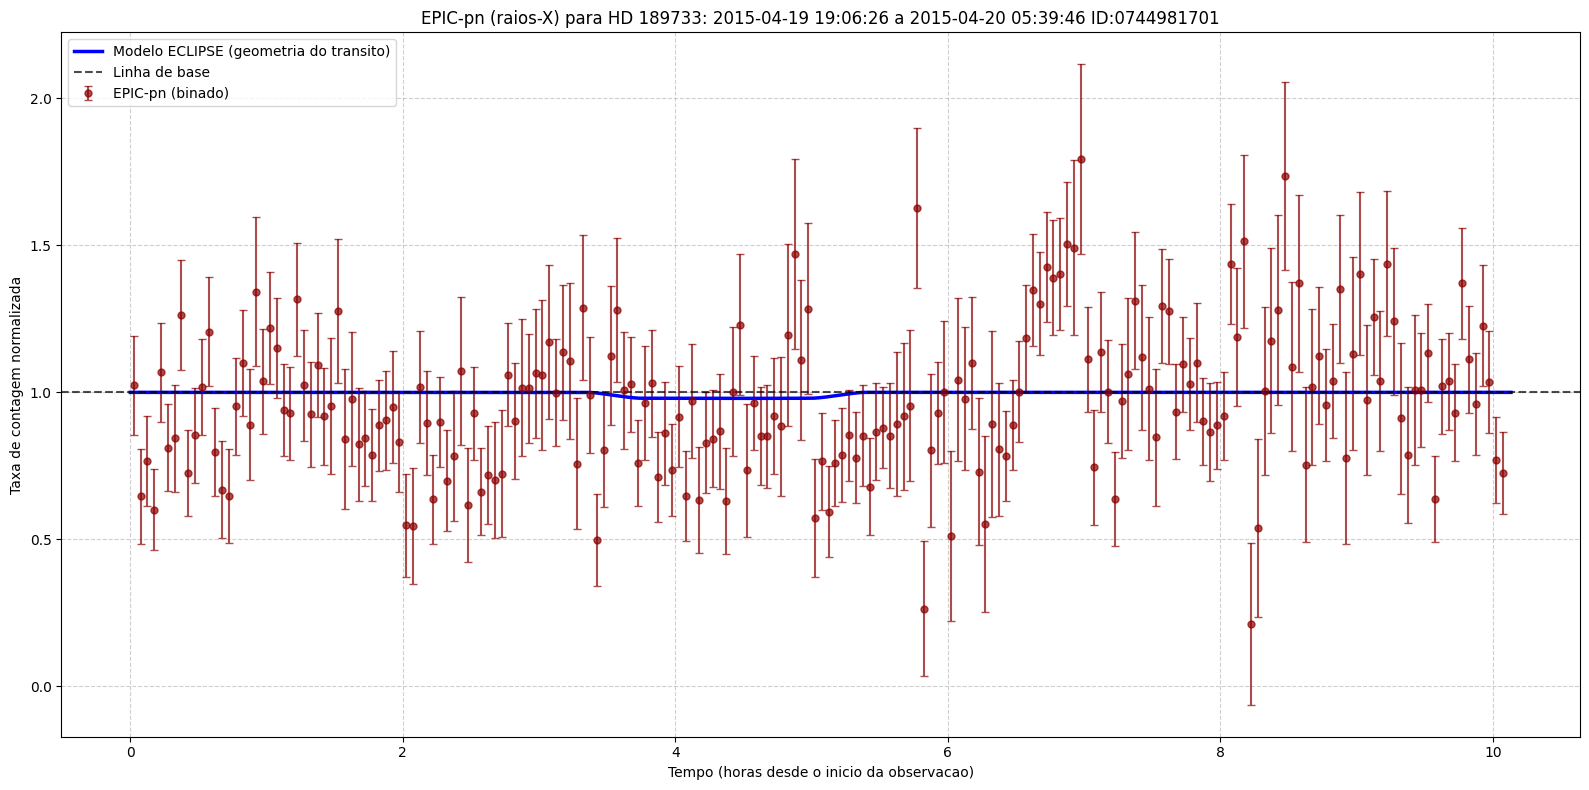

Figura salva em: 03-Products/xray/residual_xray_0744981701.png


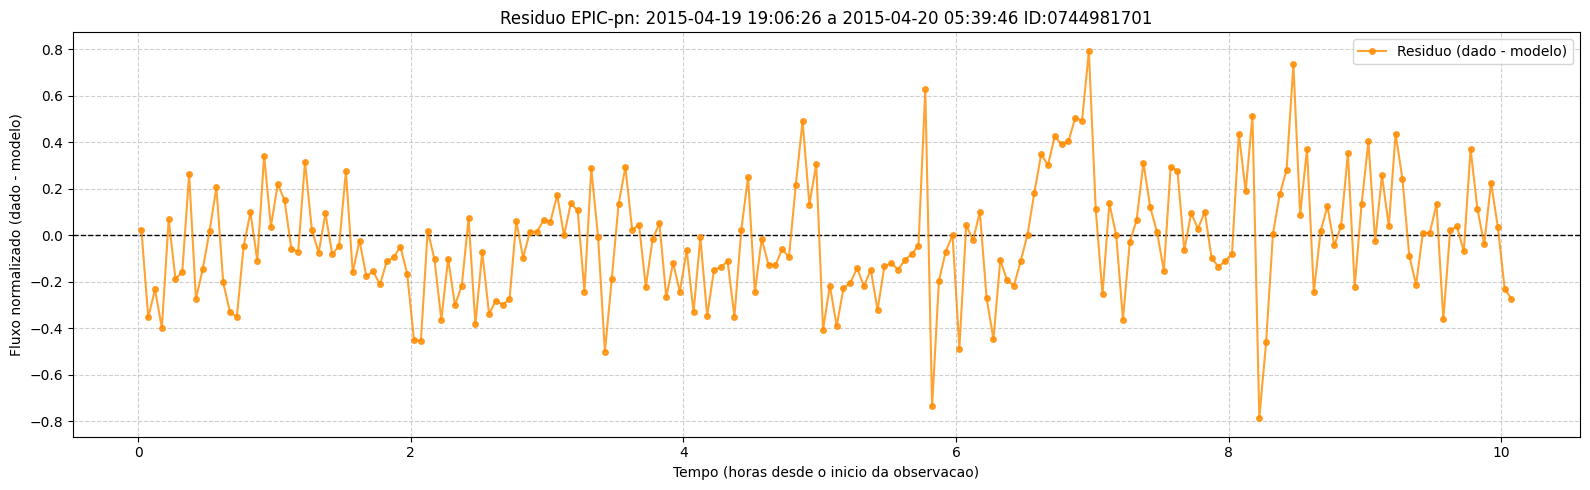


=== 2014-10-1 (ID 0744980801) ===


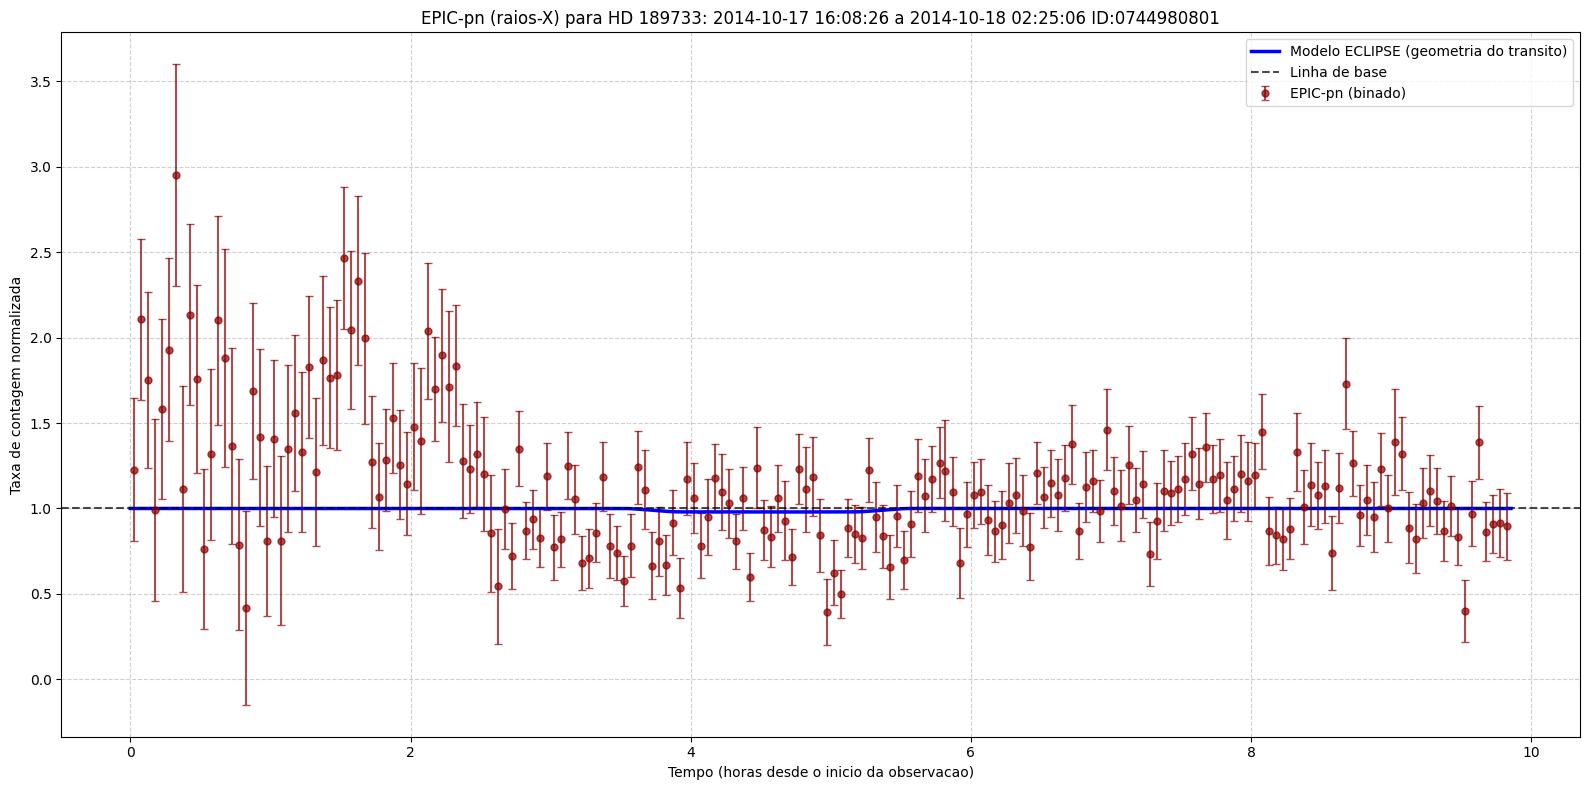

Figura salva em: 03-Products/xray/residual_xray_0744980801.png


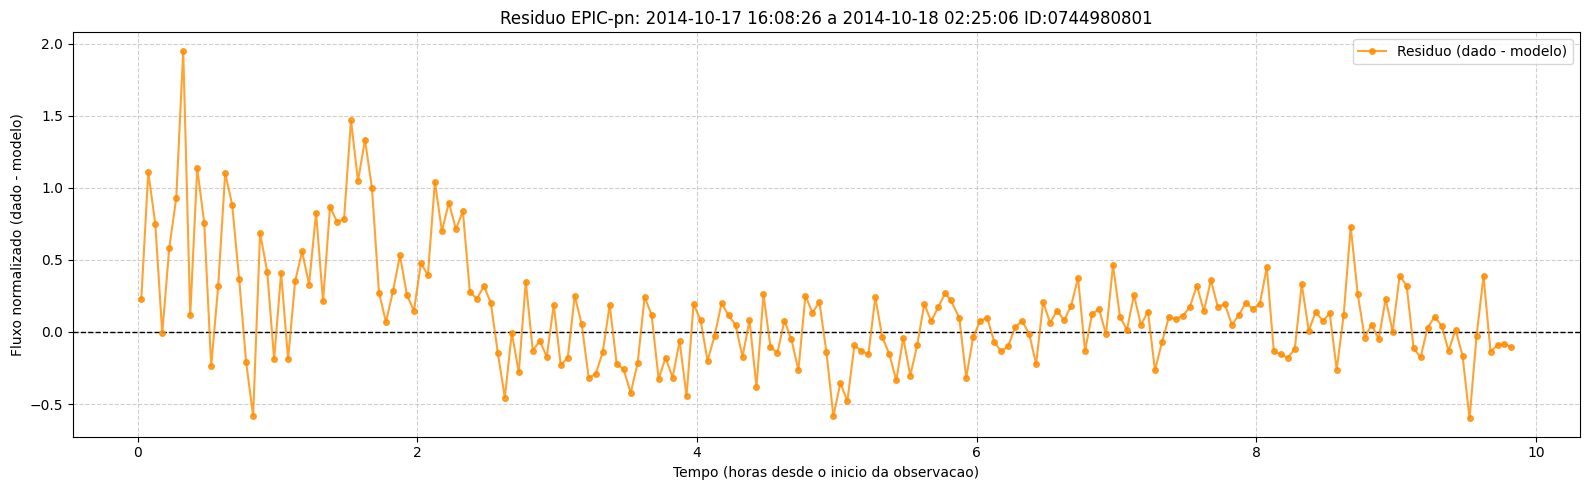


=== 2014-11-11 (ID 0744981201) ===


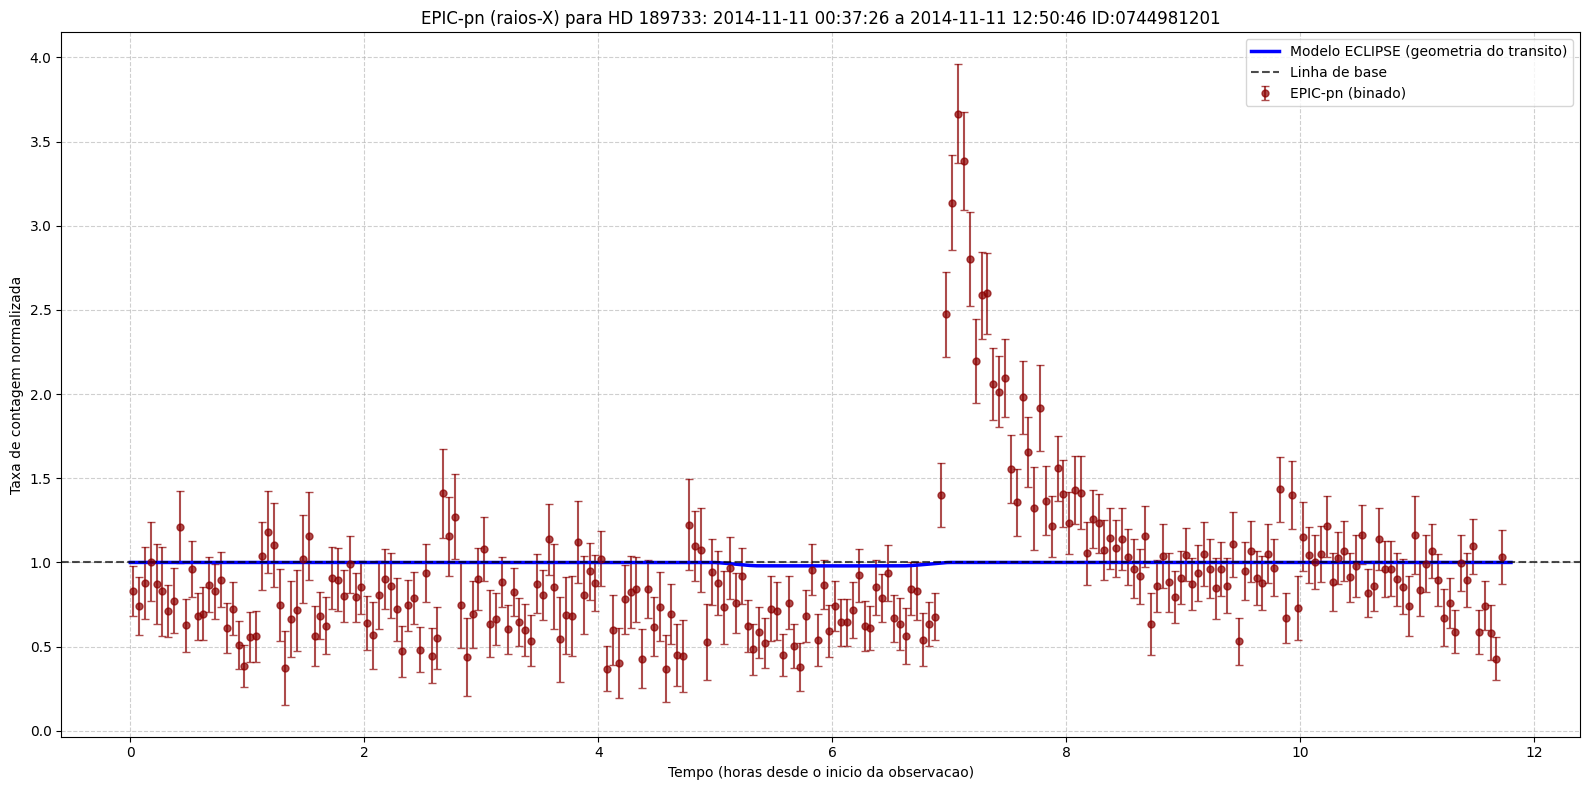

Figura salva em: 03-Products/xray/residual_xray_0744981201.png


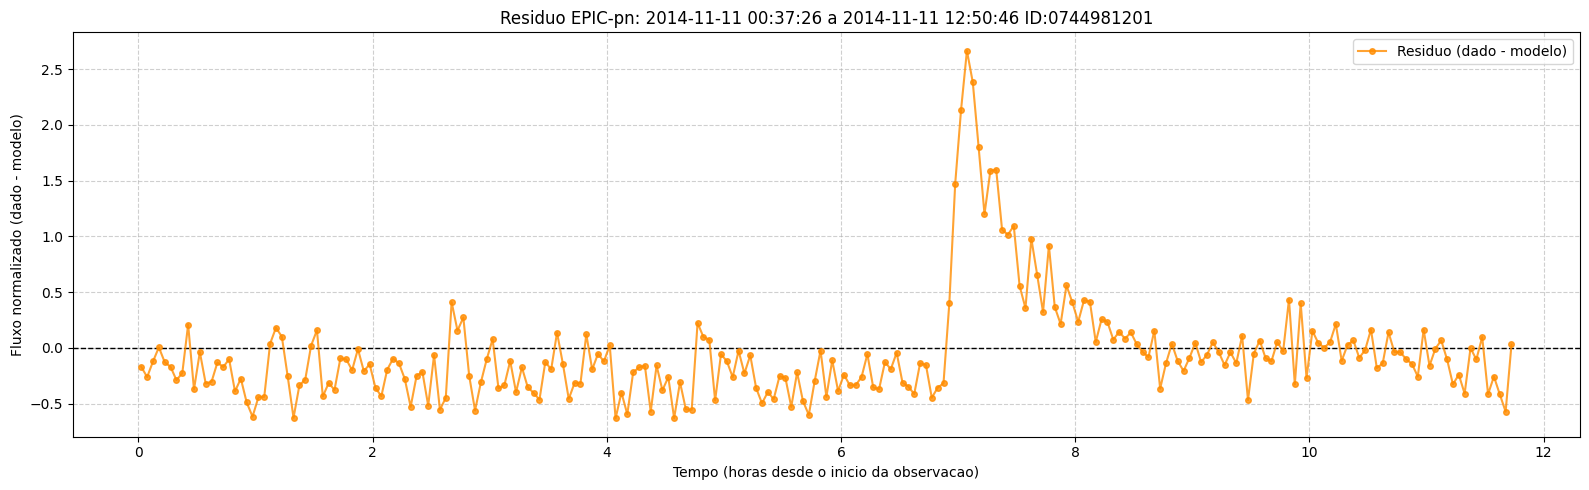


=== 2014-05-17 (ID 0744980601) ===


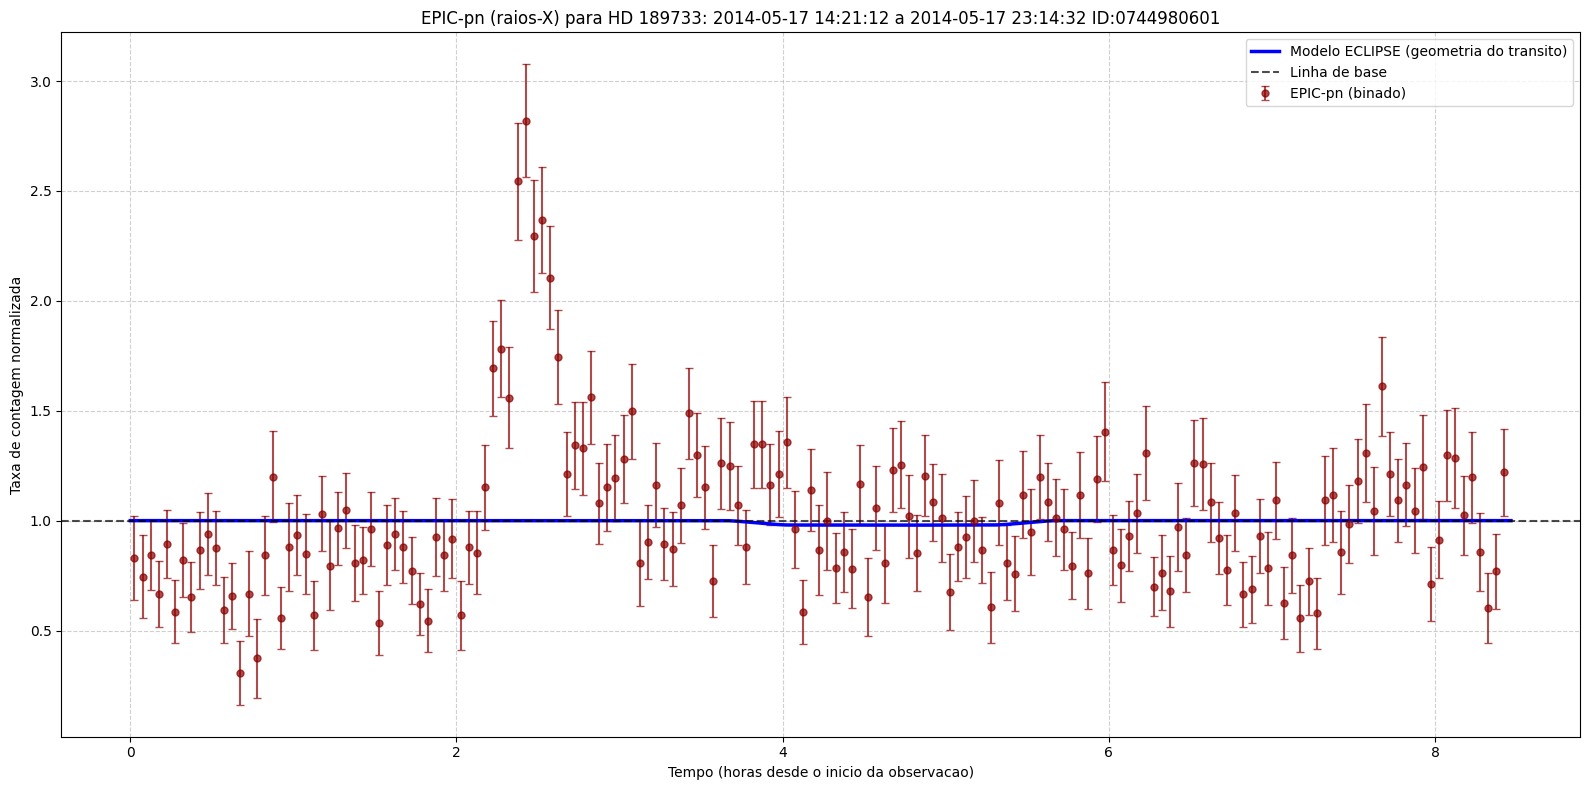

Figura salva em: 03-Products/xray/residual_xray_0744980601.png


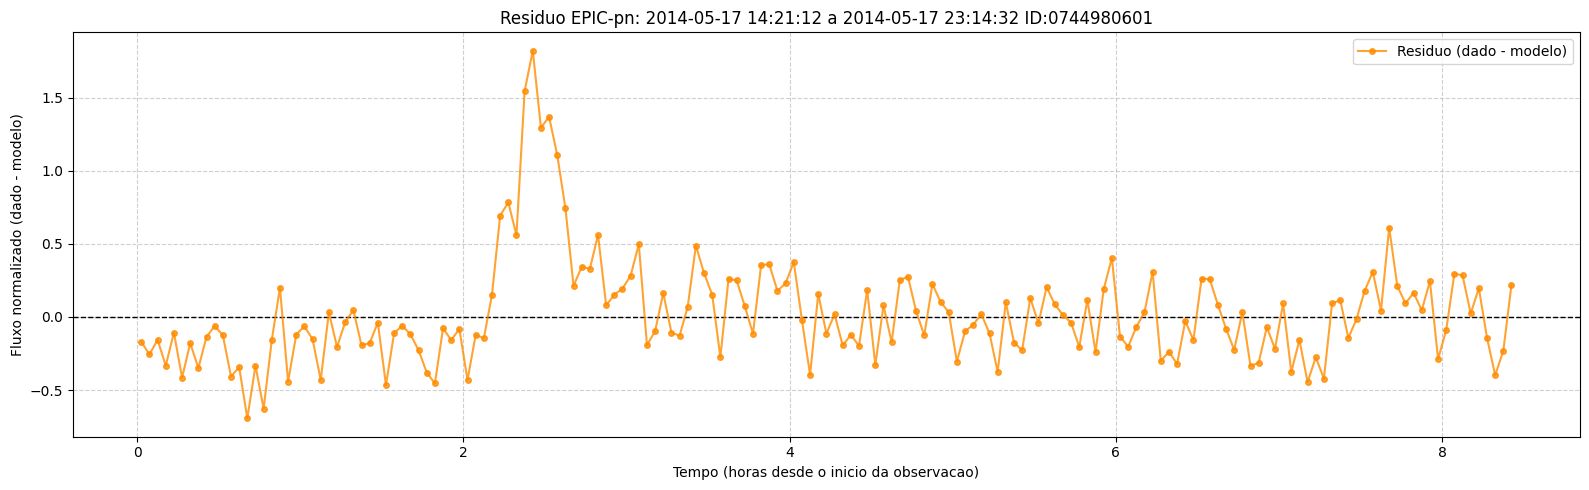


=== 2014-11-15 (ID 0744980701) ===


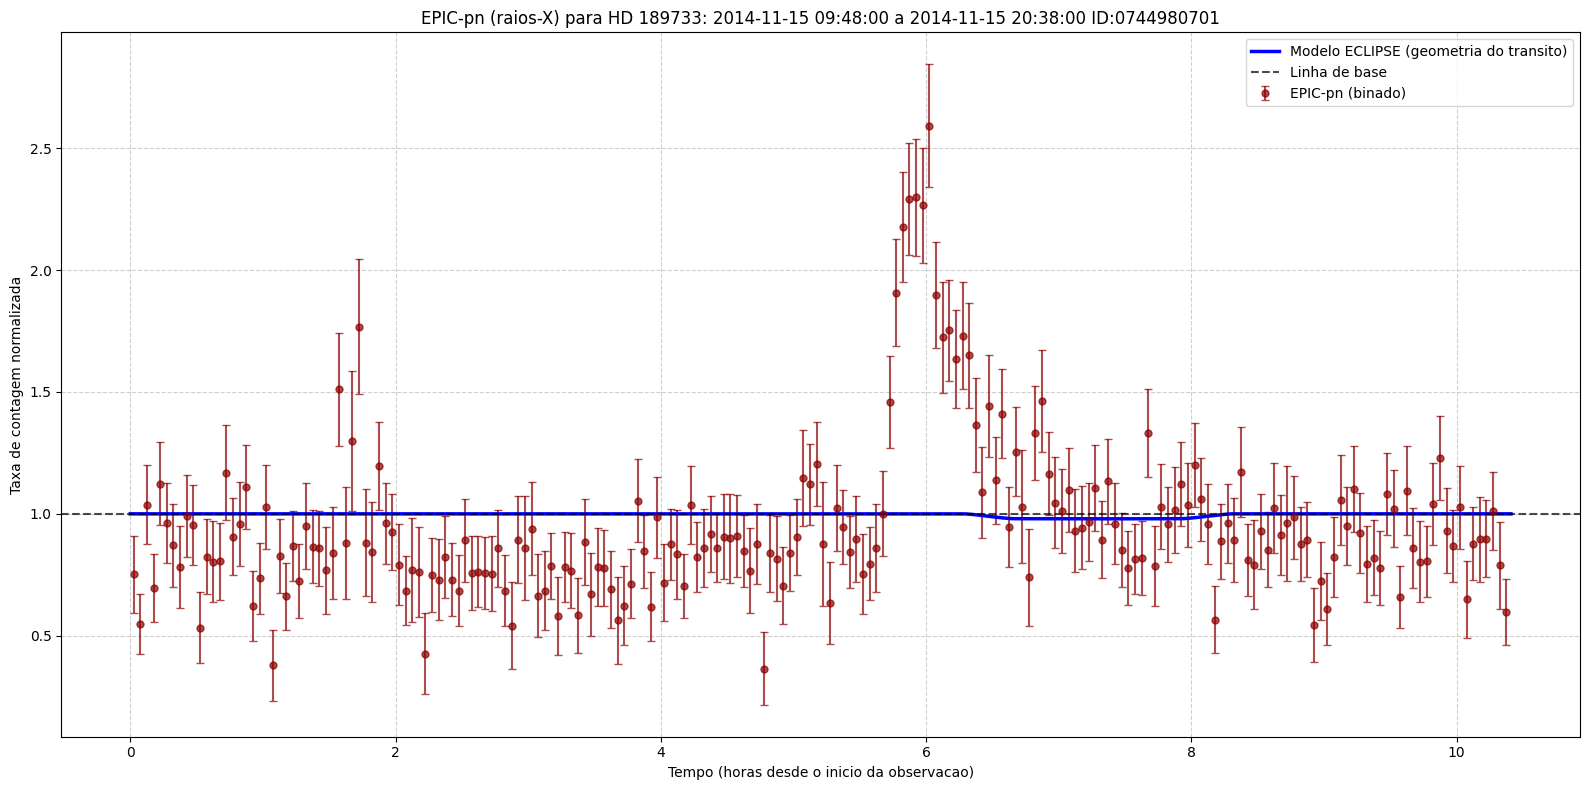

Figura salva em: 03-Products/xray/residual_xray_0744980701.png


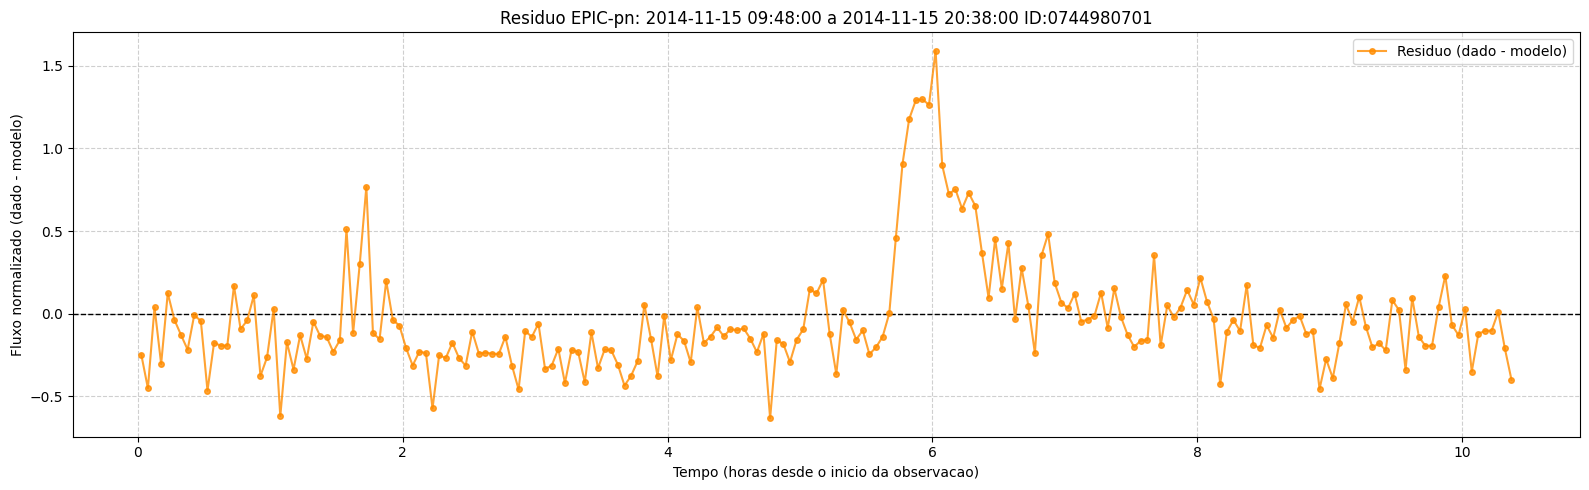

In [9]:
resultados_xray = []

for obs in observacoes:
    print(f"\n=== {obs['label']} (ID {obs['id_obs']}) ===")

    parametros_modelo['tC'] = obs['tC']

    caminho_busca = os.path.join(obs['pasta'], padrao_arquivo)
    lista_arquivos = glob.glob(caminho_busca)

    if not lista_arquivos:
        print(f"  Nenhum arquivo encontrado em {caminho_busca} -- pulando.")
        continue

    tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

    tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)
    fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

    binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados)

    plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, obs['date_obs'], obs['id_obs'])

    # Residuo: dado binado menos o modelo interpolado nos mesmos tempos
    modelo_nos_tempos_binados = modelo_de_transito_eclipse(np.array(binned_time), parametros_modelo)
    residuo = np.array(binned_flux) - modelo_nos_tempos_binados

    plot_residual(binned_time, residuo, obs['date_obs'], obs['id_obs'])

    resultados_xray.append({
        'id_obs': obs['id_obs'],
        'label': obs['label'],
        'binned_time': binned_time,
        'binned_flux': binned_flux,
        'binned_error': binned_error,
        'residuo': residuo,
    })


## Curva média (10 observações empilhadas)

Mesma lógica de `main-uv-lightcurves.ipynb`: combina todas as observações em fase orbital e bina o conjunto, para ter uma referência "estrela quieta" com a qual comparar cada observação individual — inclusive as que já sabemos serem anômalas em UV (Obs 03 e Obs 06).

 -> Processando 2007-04-17...
 -> Processando 2012-06-07...
 -> Processando 2011-05-01...
 -> Processando 2014-11-13...
 -> Processando 2015-04-17...
 -> Processando 2015-04-19...
 -> Processando 2014-10-1...
 -> Processando 2014-11-11...
 -> Processando 2014-05-17...
 -> Processando 2014-11-15...
Figura salva em: 03-Products/xray/average_lightcurve_xray_hd189733.png


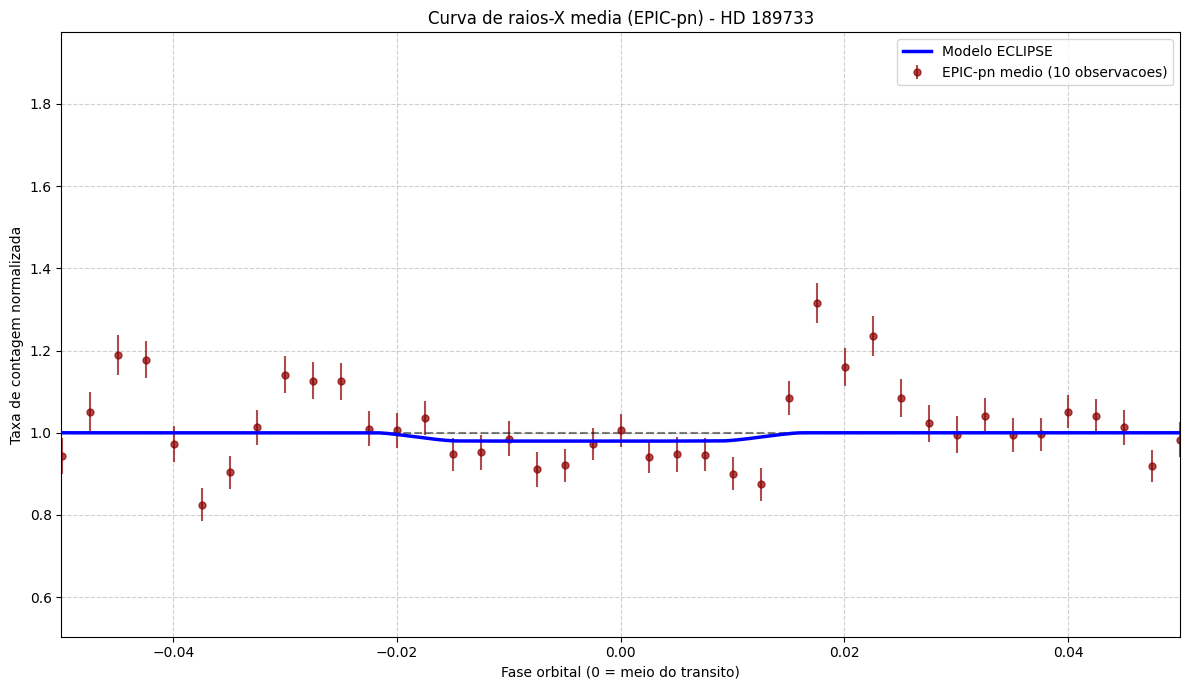

In [10]:
def processar_curva_de_luz_para_empilhar(pasta_dados, t0_centro_transito, periodo_dias, padrao=padrao_arquivo):
    caminho_busca = os.path.join(pasta_dados, padrao)
    lista_arquivos = glob.glob(caminho_busca)
    if not lista_arquivos:
        return None, None, None

    todos_tempos, todos_fluxos, todos_erros = [], [], []
    for arquivo in lista_arquivos:
        with fits.open(arquivo) as hdul:
            dados = hdul[1].data
            todos_tempos.extend(dados['TIME'])
            todos_fluxos.extend(dados['RATE'])
            todos_erros.extend(dados['ERROR'])

    todos_tempos, todos_fluxos, todos_erros = np.array(todos_tempos), np.array(todos_fluxos), np.array(todos_erros)
    indices_ordenados = np.argsort(todos_tempos)
    tempos_ordenados = todos_tempos[indices_ordenados]
    fluxos_ordenados = todos_fluxos[indices_ordenados]
    erros_ordenados = todos_erros[indices_ordenados]

    # Mesmo filtro de NaN aplicado em busca_fluxo_normalizado (ver comentario la).
    finito = np.isfinite(fluxos_ordenados) & np.isfinite(erros_ordenados)
    tempos_ordenados = tempos_ordenados[finito]
    fluxos_ordenados = fluxos_ordenados[finito]
    erros_ordenados = erros_ordenados[finito]

    tempos_em_horas = (tempos_ordenados - tempos_ordenados[0]) / 3600.0

    mask_fora_transito = np.abs(tempos_em_horas - t0_centro_transito) > 1.5
    fluxo_fora_transito = np.mean(fluxos_ordenados[mask_fora_transito])
    fluxos_normalizados = fluxos_ordenados / fluxo_fora_transito
    erros_normalizados = erros_ordenados / fluxo_fora_transito

    periodo_em_horas = periodo_dias * 24.0
    fase_observada = (tempos_em_horas - t0_centro_transito) / periodo_em_horas

    return fase_observada, fluxos_normalizados, erros_normalizados


periodo_geral_dias = 2.21857520

todas_as_fases, todos_os_fluxos = [], []
for obs in observacoes:
    print(f" -> Processando {obs['label']}...")
    fase, fluxo, _ = processar_curva_de_luz_para_empilhar(obs['pasta'], obs['tC'], periodo_geral_dias)
    if fase is None:
        print(f"    (sem arquivo pn, pulando)")
        continue
    todas_as_fases.append(fase)
    todos_os_fluxos.append(fluxo)

fases_combinadas = np.concatenate(todas_as_fases)
fluxos_combinados = np.concatenate(todos_os_fluxos)

bin_size_fase = 0.0025
bins = np.arange(fases_combinadas.min(), fases_combinadas.max(), bin_size_fase)
binned_fase, binned_flux_medio, binned_error_medio = [], [], []
for i in range(len(bins) - 1):
    mask = (fases_combinadas >= bins[i]) & (fases_combinadas < bins[i + 1])
    if np.sum(mask) > 1:
        binned_fase.append(np.mean(fases_combinadas[mask]))
        binned_flux_medio.append(np.mean(fluxos_combinados[mask]))
        n_points = len(fluxos_combinados[mask])
        binned_error_medio.append(np.std(fluxos_combinados[mask]) / np.sqrt(n_points))

parametros_modelo_medio = dict(parametros_modelo)
parametros_modelo_medio['tC'] = 0.0

fase_modelo_plot = np.linspace(-0.05, 0.05, 1000)
periodo_em_horas = periodo_geral_dias * 24.0
tempo_modelo_horas = fase_modelo_plot * periodo_em_horas
fluxo_do_seu_modelo_medio = modelo_de_transito_eclipse(tempo_modelo_horas, parametros_modelo_medio)

plt.figure(figsize=(12, 7))
plt.errorbar(binned_fase, binned_flux_medio, yerr=binned_error_medio, fmt='o', markersize=5, color='darkred', ecolor='darkred', capsize=0, alpha=0.7, label=f'EPIC-pn medio ({len(todas_as_fases)} observacoes)')
plt.plot(fase_modelo_plot, fluxo_do_seu_modelo_medio, color='blue', linewidth=2.5, zorder=10, label='Modelo ECLIPSE')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5)
plt.title('Curva de raios-X media (EPIC-pn) - HD 189733')
plt.xlabel('Fase orbital (0 = meio do transito)')
plt.ylabel('Taxa de contagem normalizada')
plt.xlim(-0.05, 0.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

output_dir = '03-Products/xray'
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, 'average_lightcurve_xray_hd189733.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"Figura salva em: {file_path}")
plt.show()


## Próximos passos

- Inspecionar visualmente os resíduos de cada observação (salvos em `03-Products/xray/residual_xray_<ID>.png`) — procurar por qualquer desvio sistemático em relação ao modelo geométrico puro, especialmente nas observações que já mostraram anomalia em UVM2 (Obs 03 = `0672390201`, Obs 06 = `0744981701`, conferir os IDs certos contra a numeração usada no restante do projeto).
- Se algo aparecer, o próximo passo natural é tentar ajustar os mesmos modelos geométricos de CME (Cápsula/Gota) usados em UV, agora ao resíduo de raios-X — mesma abordagem de `main-uv-lightcurves.ipynb`, seção de MCMC.
- Considerar somar MOS1+MOS2+pn para mais estatística, se o resíduo em pn sozinho for promissor mas ruidoso demais para confirmar.
- Revisitar os coeficientes de limb darkening (`u1`, `u2`) com um valor mais apropriado para raios-X, se a forma do trânsito no modelo não bater bem com os dados binados.

## Resíduo restrito à janela do trânsito

O resíduo calculado sobre a observação inteira (~15h) não diferenciou Obs 03 (`0672390201`) e Obs 06 (`0744981701`) das outras 8 — todas ficaram na mesma faixa de dispersão (`std` do resíduo entre 0.21 e 0.47), dominada por variabilidade real de flares da estrela ao longo de toda a observação, fora do trânsito.

Esta seção **acrescenta** uma nova análise às células acima, sem alterar nada nelas: restringe o cálculo do resíduo a uma janela em torno do centro do trânsito (`tC`), replicando mais de perto o processo que efetivamente encontrou a anomalia original em UVM2 (que também olhava só a região do trânsito, não a observação inteira). A ideia é que a variabilidade de flares fora do trânsito pode estar mascarando qualquer sinal específico da passagem planetária quando se olha o resíduo completo.

A largura da janela (`±1.5h` em torno de `tC`) usa o mesmo critério já definido em `processar_curva_de_luz_para_empilhar` para separar "dentro" de "fora" do trânsito (`mask_fora_transito`), mantendo consistência com o resto do notebook.

In [11]:
LARGURA_JANELA_TRANSITO_HORAS = 1.5  # mesma largura usada como "dentro do transito" em mask_fora_transito (processar_curva_de_luz_para_empilhar)


def residuo_na_janela_do_transito(binned_time, residuo, tC, meia_largura_horas=LARGURA_JANELA_TRANSITO_HORAS):
    """Recorta o residuo binado para os pontos dentro de +-meia_largura_horas do centro do transito."""
    binned_time = np.array(binned_time)
    residuo = np.array(residuo)
    mask = np.abs(binned_time - tC) <= meia_largura_horas
    return binned_time[mask], residuo[mask]


def plot_residual_janela_transito(binned_time, residuo, tC, date_obs, id_obs, output_dir='03-Products/xray'):
    """Mesmo que plot_residual, mas restrito a janela em torno do centro do transito (tC)."""
    plt.figure(figsize=(10, 5))
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.axvline(tC, color='gray', linestyle=':', linewidth=1, label='Centro do transito (tC)')
    if len(binned_time) > 0:
        plt.plot(binned_time, residuo, 'o-', color='darkorange', markersize=5, alpha=0.8, label='Residuo (dado - modelo)')
    plt.title('Residuo EPIC-pn na janela do transito: ' + date_obs + " ID:" + id_obs)
    plt.xlabel('Tempo (horas desde o inicio da observacao)')
    plt.ylabel('Fluxo normalizado (dado - modelo)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    os.makedirs(output_dir, exist_ok=True)
    file_path = os.path.join(output_dir, f"residual_xray_transit_window_{id_obs}.png")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    print(f"Figura salva em: {file_path}")
    plt.show()


Figura salva em: 03-Products/xray/residual_xray_transit_window_0506070201.png


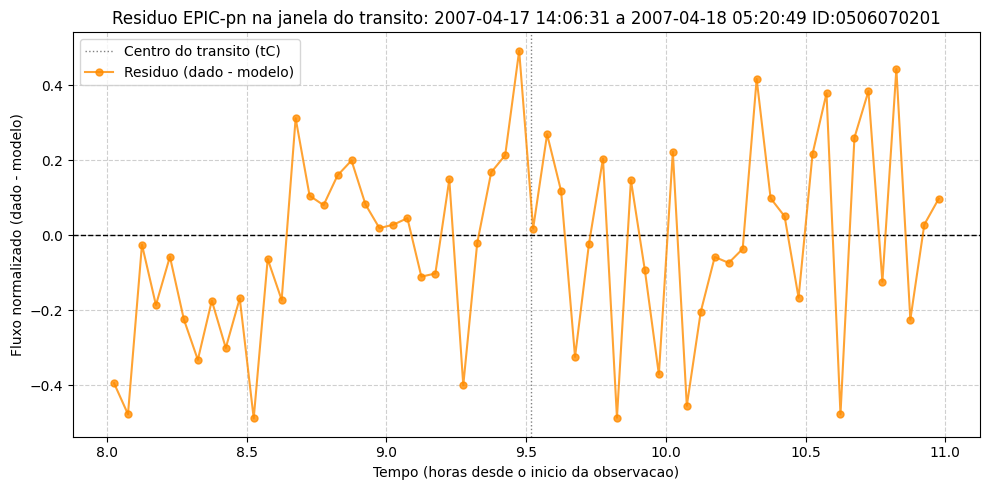

Figura salva em: 03-Products/xray/residual_xray_transit_window_0690890201.png


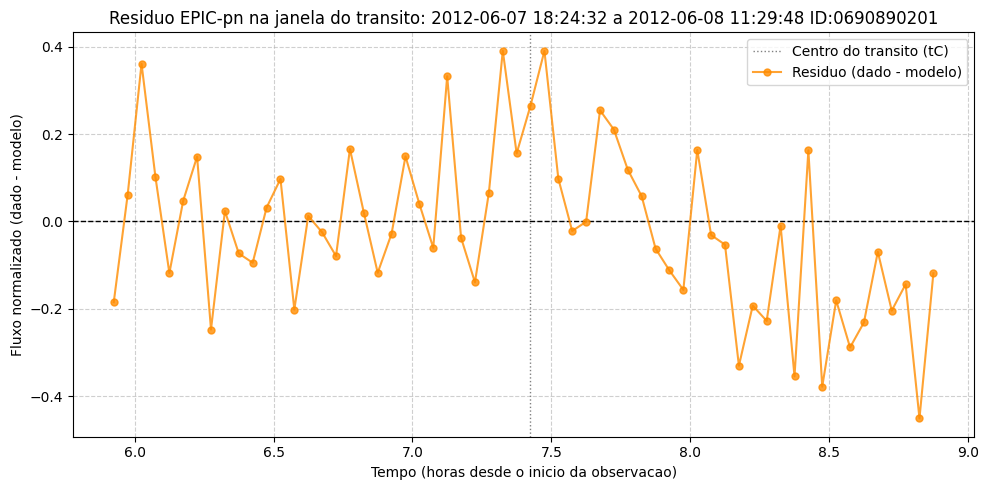

Figura salva em: 03-Products/xray/residual_xray_transit_window_0672390201.png


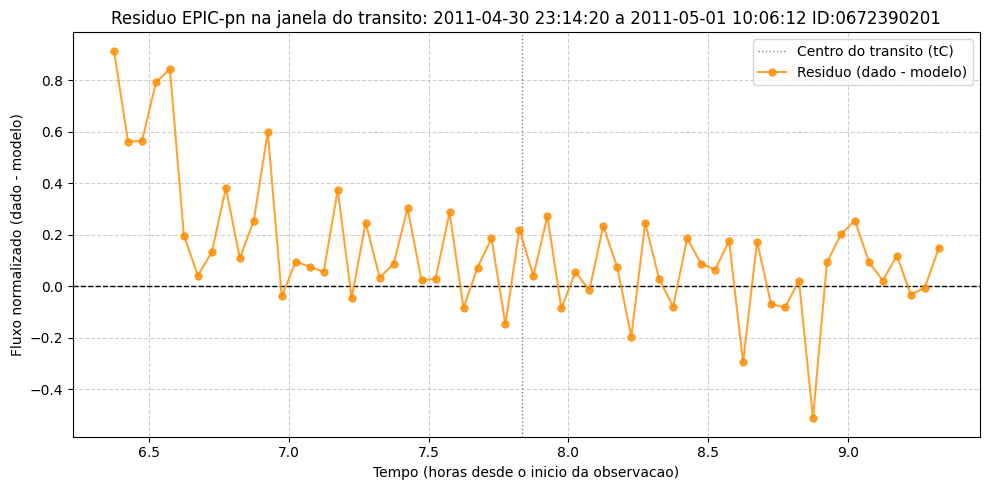

Figura salva em: 03-Products/xray/residual_xray_transit_window_0744981401.png


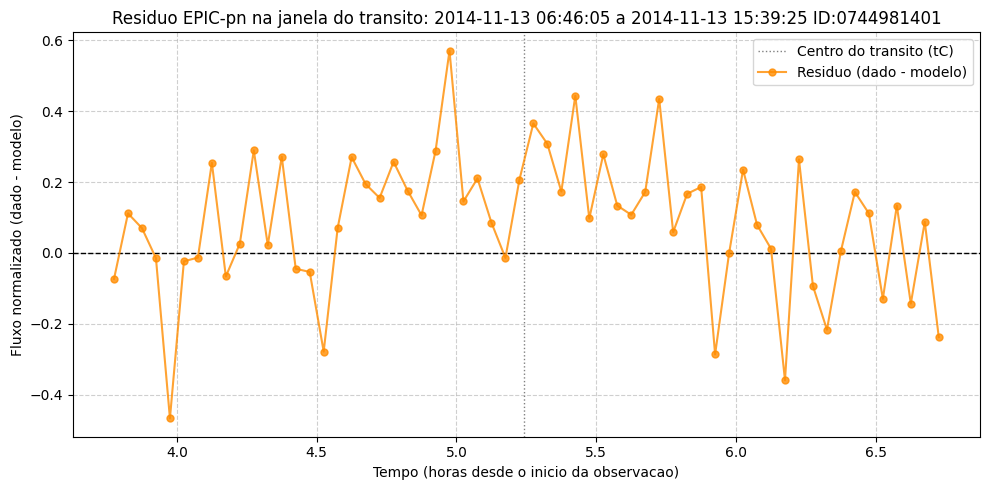

Figura salva em: 03-Products/xray/residual_xray_transit_window_0744981601.png


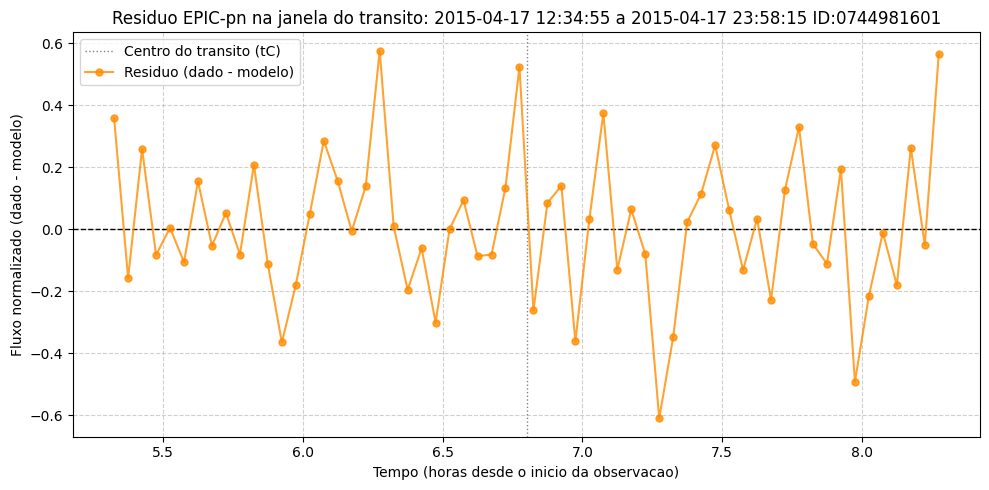

Figura salva em: 03-Products/xray/residual_xray_transit_window_0744981701.png


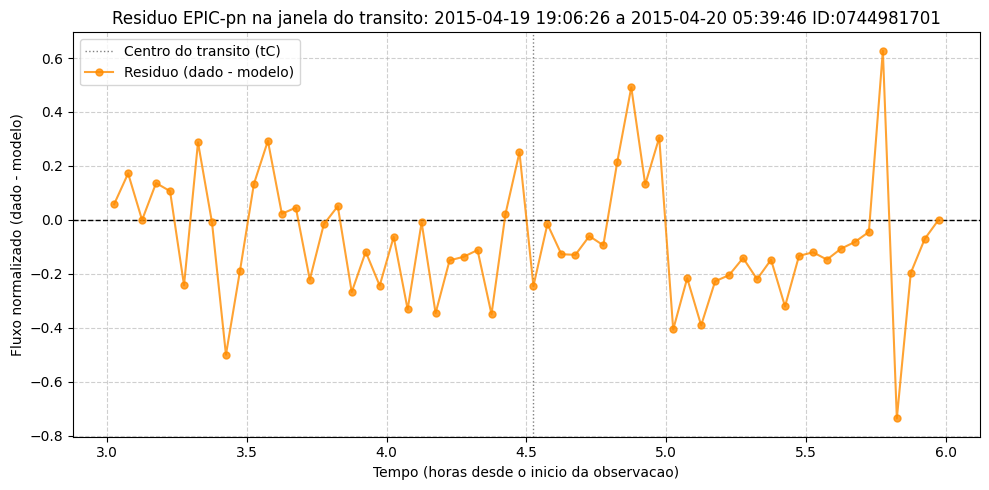

Figura salva em: 03-Products/xray/residual_xray_transit_window_0744980801.png


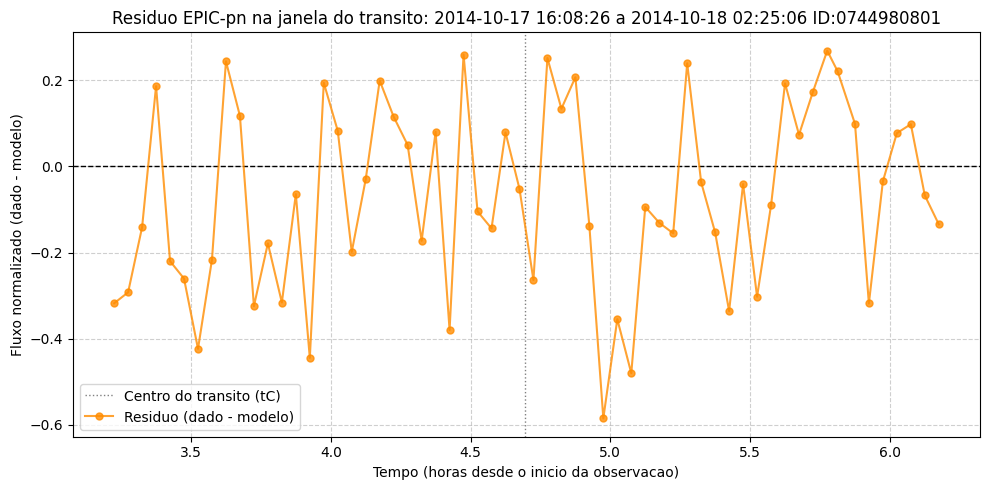

Figura salva em: 03-Products/xray/residual_xray_transit_window_0744981201.png


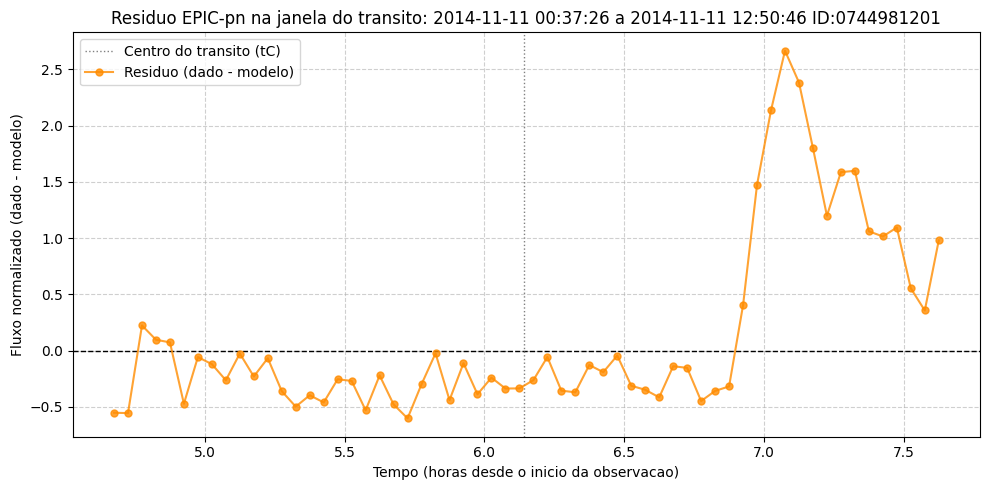

Figura salva em: 03-Products/xray/residual_xray_transit_window_0744980601.png


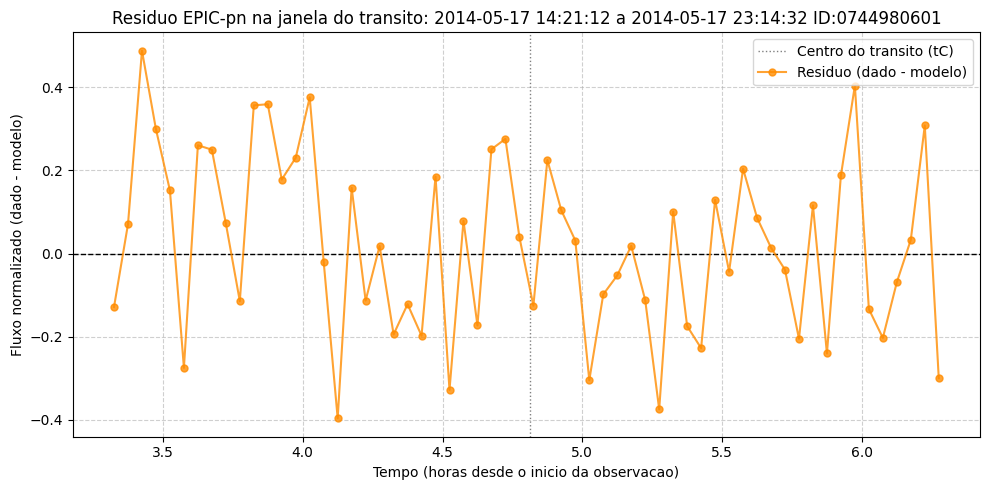

Figura salva em: 03-Products/xray/residual_xray_transit_window_0744980701.png


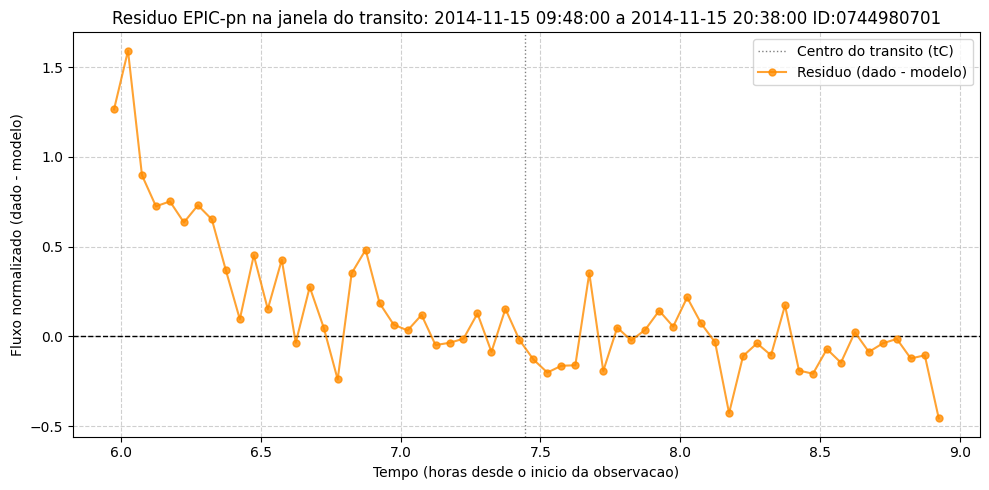

In [12]:
tC_por_obs = {obs['id_obs']: obs['tC'] for obs in observacoes}
label_por_obs = {obs['id_obs']: obs['label'] for obs in observacoes}
date_por_obs = {obs['id_obs']: obs['date_obs'] for obs in observacoes}

resumo_janela_transito = []

for resultado in resultados_xray:
    id_obs = resultado['id_obs']
    tC = tC_por_obs[id_obs]

    tempo_janela, residuo_janela = residuo_na_janela_do_transito(resultado['binned_time'], resultado['residuo'], tC)
    std_completo = np.std(resultado['residuo'])
    std_janela = np.std(residuo_janela) if len(residuo_janela) > 0 else np.nan

    plot_residual_janela_transito(tempo_janela, residuo_janela, tC, date_por_obs[id_obs], id_obs)

    resumo_janela_transito.append({
        'id_obs': id_obs,
        'label': label_por_obs[id_obs],
        'std_residuo_completo': std_completo,
        'std_residuo_janela_transito': std_janela,
        'n_pontos_janela': len(residuo_janela),
    })


In [13]:
print("Resumo: dispersao do residuo (observacao inteira) vs (janela do transito)\n")
print(f"{'ID':<12} {'Data':<12} {'std completo':>14} {'std janela':>12} {'n pontos':>10}")

ids_anomalos_uv = {'0672390201', '0744981701'}
for r in resumo_janela_transito:
    marcador = '  <- anomala em UVM2' if r['id_obs'] in ids_anomalos_uv else ''
    print(f"{r['id_obs']:<12} {r['label']:<12} {r['std_residuo_completo']:>14.4f} {r['std_residuo_janela_transito']:>12.4f} {r['n_pontos_janela']:>10}{marcador}")


Resumo: dispersao do residuo (observacao inteira) vs (janela do transito)

ID           Data           std completo   std janela   n pontos
0506070201   2007-04-17           0.3277       0.2498         60
0690890201   2012-06-07           0.2468       0.1868         60
0672390201   2011-05-01           0.2555       0.2478         60  <- anomala em UVM2
0744981401   2014-11-13           0.2090       0.1944         60
0744981601   2015-04-17           0.3038       0.2358         60
0744981701   2015-04-19           0.2496       0.2284         60  <- anomala em UVM2
0744980801   2014-10-1            0.3875       0.2165         60
0744981201   2014-11-11           0.4740       0.7943         60
0744980601   2014-05-17           0.3617       0.2127         60
0744980701   2014-11-15           0.3350       0.3735         60


## Resíduo médio (não só dispersão) na janela do trânsito

O teste anterior olhou só a dispersão (`std`) do resíduo dentro da janela do trânsito, e não diferenciou Obs 03/06 das outras. Mas um dimming sistemático e pequeno pode não aumentar a dispersão — ele desloca a **média** do resíduo pra baixo (ou pra cima, se for excesso de brilho tipo flare/arco associado à erupção) sem necessariamente deixar o resíduo mais "espalhado" ao redor de zero.

Esta seção **acrescenta** mais uma análise, sem alterar nada acima: reaproveita `resultados_xray` e `residuo_na_janela_do_transito` (já definidos) para calcular a média do resíduo dentro da mesma janela (±1.5h em torno de `tC`) e seu erro padrão, checando se existe um viés sistemático que o `std` sozinho não capturaria.

In [14]:
resumo_media_janela_transito = []

for resultado in resultados_xray:
    id_obs = resultado['id_obs']
    tC = tC_por_obs[id_obs]

    _, residuo_janela = residuo_na_janela_do_transito(resultado['binned_time'], resultado['residuo'], tC)
    media_janela = np.mean(residuo_janela) if len(residuo_janela) > 0 else np.nan
    erro_padrao_media = np.std(residuo_janela) / np.sqrt(len(residuo_janela)) if len(residuo_janela) > 0 else np.nan

    resumo_media_janela_transito.append({
        'id_obs': id_obs,
        'label': label_por_obs[id_obs],
        'media_residuo_janela': media_janela,
        'erro_padrao_media': erro_padrao_media,
    })

print("Resumo: media do residuo na janela do transito (+- erro padrao da media)\n")
print(f"{'ID':<12} {'Data':<12} {'media':>10} {'erro padrao':>12} {'media/erro':>12}")
for r in resumo_media_janela_transito:
    marcador = '  <- anomala em UVM2' if r['id_obs'] in ids_anomalos_uv else ''
    razao = r['media_residuo_janela'] / r['erro_padrao_media'] if r['erro_padrao_media'] else np.nan
    print(f"{r['id_obs']:<12} {r['label']:<12} {r['media_residuo_janela']:>10.4f} {r['erro_padrao_media']:>12.4f} {razao:>12.2f}{marcador}")


Resumo: media do residuo na janela do transito (+- erro padrao da media)

ID           Data              media  erro padrao   media/erro
0506070201   2007-04-17      -0.0238       0.0323        -0.74
0690890201   2012-06-07      -0.0183       0.0241        -0.76
0672390201   2011-05-01       0.1391       0.0320         4.35  <- anomala em UVM2
0744981401   2014-11-13       0.0882       0.0251         3.52
0744981601   2015-04-17       0.0087       0.0304         0.29
0744981701   2015-04-19      -0.0759       0.0295        -2.57  <- anomala em UVM2
0744980801   2014-10-1       -0.0725       0.0280        -2.60
0744981201   2014-11-11       0.1374       0.1025         1.34
0744980601   2014-05-17       0.0215       0.0275         0.78
0744980701   2014-11-15       0.1367       0.0482         2.83


Figura salva em: 03-Products/xray/mean_residual_transit_window_hd189733.png


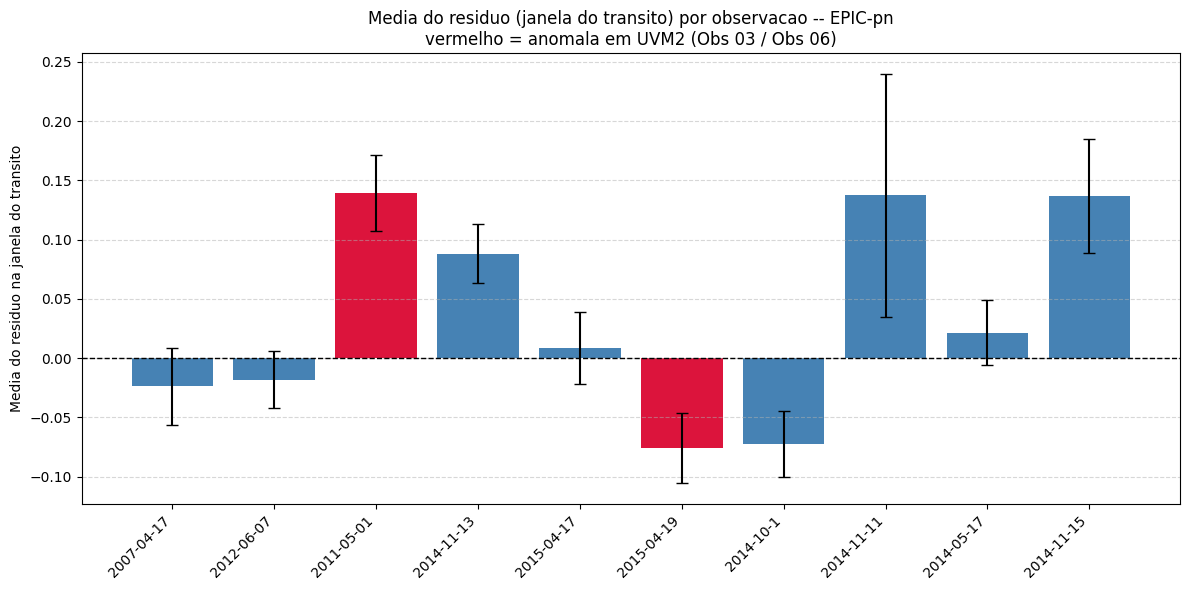

In [15]:
ids_plot = [r['id_obs'] for r in resumo_media_janela_transito]
medias_plot = [r['media_residuo_janela'] for r in resumo_media_janela_transito]
erros_plot = [r['erro_padrao_media'] for r in resumo_media_janela_transito]
cores_plot = ['crimson' if id_obs in ids_anomalos_uv else 'steelblue' for id_obs in ids_plot]

plt.figure(figsize=(12, 6))
plt.bar(range(len(ids_plot)), medias_plot, yerr=erros_plot, color=cores_plot, capsize=4)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xticks(range(len(ids_plot)), [label_por_obs[i] for i in ids_plot], rotation=45, ha='right')
plt.ylabel('Media do residuo na janela do transito')
plt.title('Media do residuo (janela do transito) por observacao -- EPIC-pn\nvermelho = anomala em UVM2 (Obs 03 / Obs 06)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

output_dir = '03-Products/xray'
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, 'mean_residual_transit_window_hd189733.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"Figura salva em: {file_path}")
plt.show()


## χ²_ν comparado à curva média (mesma estatística usada em UVM2)

As análises acima (`std` e média do resíduo, ambas contra o **modelo geométrico puro** do ECLIPSE) usam uma referência diferente da que originalmente encontrou a anomalia em Obs 03/06 em UVM2 (`main-uv-lightcurves.ipynb`). Lá, cada observação é comparada contra a **curva média empírica das 10 observações** (não contra o modelo puro), e o resíduo é normalizado pela incerteza fotométrica combinada antes de virar χ²:

```python
residuos = binned_fluxo_alvo - fluxo_medio_interp   # obs individual - curva média empírica
erro_residuos = np.sqrt(binned_erro_alvo**2 + erro_medio_interp**2)
qui_quadrado_reduzido = np.sum((residuos / erro_residuos) ** 2) / graus_de_liberdade
```

Isso importa porque comparar contra a curva média cancela efeitos sistemáticos comuns a todas as observações (ex.: atividade de flare típica da estrela, que aparece em todas), deixando no resíduo principalmente o que é **específico** de cada observação — diferente de comparar contra o modelo puro, onde esse ruído comum permanece em todas as observações por igual e pode mascarar uma anomalia pontual.

Esta seção **acrescenta** essa análise ao notebook (nada acima foi alterado), replicando exatamente a mesma estatística usada em UVM2, agora com os dados de raios-X — para ter um número diretamente comparável à tabela de χ²_ν já obtida em UV. Reaproveita `processar_curva_de_luz_para_empilhar`, `binned_fase`/`binned_flux_medio`/`binned_error_medio` (curva média, já calculados na seção "Curva média" acima) e `bin_size_fase`.

In [16]:
def binar_por_fase(fase, fluxo, bin_size=bin_size_fase):
    """Bina uma curva individual (fase, fluxo) em bins de fase de largura fixa.
    Mesma logica de binagem usada para a observacao alvo em main-uv-lightcurves.ipynb."""
    fase = np.array(fase)
    fluxo = np.array(fluxo)
    bins = np.arange(fase.min(), fase.max(), bin_size)
    binned_fase_, binned_fluxo_, binned_erro_ = [], [], []
    for i in range(len(bins) - 1):
        mask = (fase >= bins[i]) & (fase < bins[i + 1])
        if np.sum(mask) > 0:
            binned_fase_.append(np.mean(fase[mask]))
            binned_fluxo_.append(np.mean(fluxo[mask]))
            n_points = np.sum(mask)
            binned_erro_.append(np.std(fluxo[mask]) / np.sqrt(n_points))
    return np.array(binned_fase_), np.array(binned_fluxo_), np.array(binned_erro_)


In [17]:
resumo_chi2_xray = []

for obs in observacoes:
    fase_alvo, fluxo_alvo, erro_alvo = processar_curva_de_luz_para_empilhar(obs['pasta'], obs['tC'], periodo_geral_dias)
    if fase_alvo is None:
        print(f"  Sem arquivo pn para {obs['label']} -- pulando.")
        continue

    binned_fase_alvo, binned_fluxo_alvo, binned_erro_alvo = binar_por_fase(fase_alvo, fluxo_alvo)

    fluxo_medio_interp = np.interp(binned_fase_alvo, binned_fase, binned_flux_medio)
    erro_medio_interp = np.interp(binned_fase_alvo, binned_fase, binned_error_medio)

    residuos = binned_fluxo_alvo - fluxo_medio_interp
    erro_residuos = np.sqrt(binned_erro_alvo**2 + erro_medio_interp**2)

    qui_quadrado = np.sum((residuos / erro_residuos) ** 2)
    graus_de_liberdade = len(residuos) - 1
    qui_quadrado_reduzido = qui_quadrado / graus_de_liberdade if graus_de_liberdade > 0 else np.nan

    if 0.7 <= qui_quadrado_reduzido <= 1.5:
        interpretacao = "Consistente com ruido (normal)"
    elif qui_quadrado_reduzido > 1.5:
        interpretacao = "Anomala (sinal > ruido esperado)"
    else:
        interpretacao = "Erro superestimado (< 0.7)"

    resumo_chi2_xray.append({
        'id_obs': obs['id_obs'],
        'label': obs['label'],
        'chi2_reduzido': qui_quadrado_reduzido,
        'interpretacao': interpretacao,
    })

print(f"{'ID':<12} {'Data':<12} {'chi2_nu':>10}  Interpretacao")
for r in resumo_chi2_xray:
    marcador = '  <- anomala em UVM2' if r['id_obs'] in ids_anomalos_uv else ''
    print(f"{r['id_obs']:<12} {r['label']:<12} {r['chi2_reduzido']:>10.4f}  {r['interpretacao']}{marcador}")


ID           Data            chi2_nu  Interpretacao
0506070201   2007-04-17       1.1855  Consistente com ruido (normal)
0690890201   2012-06-07       3.6214  Anomala (sinal > ruido esperado)
0672390201   2011-05-01       2.7370  Anomala (sinal > ruido esperado)  <- anomala em UVM2
0744981401   2014-11-13       2.2144  Anomala (sinal > ruido esperado)
0744981601   2015-04-17       3.0493  Anomala (sinal > ruido esperado)
0744981701   2015-04-19       2.3197  Anomala (sinal > ruido esperado)  <- anomala em UVM2
0744980801   2014-10-1        4.4768  Anomala (sinal > ruido esperado)
0744981201   2014-11-11       7.5867  Anomala (sinal > ruido esperado)
0744980601   2014-05-17       5.3338  Anomala (sinal > ruido esperado)
0744980701   2014-11-15       4.8510  Anomala (sinal > ruido esperado)


## Comparação de modelo aninhado: Δχ² com CME (Gota, geometrias fixas validadas em UV)

Os 3 testes acima (`std`, média, χ²_ν vs. curva média) são todos estatísticas **agregadas**: perguntam "o desvio é grande?", não "o desvio tem a forma certa?". Um flare aleatório e uma CME real produzem desvios de magnitude parecida, mas com perfis temporais diferentes (pico isolado e assimétrico vs. rampa suave e ligada à geometria do trânsito). Esta seção testa **forma**, não só magnitude — comparação de modelo aninhado.

**Correção (2026-08-24)**: a primeira versão desta seção usava parâmetros que, por engano, correspondiam à geometria Gota de **Obs 06** rotulados como Obs 03 — o resultado impresso originalmente ("Obs 03 Gota") na verdade era Obs 06. Corrigido abaixo usando a tabela publicada no artigo (parâmetros MCMC, incerteza 16º-84º percentil), com as **duas** geometrias Gota (Obs 3 e Obs 6) — Cápsula não usada aqui por indicação de que Gota foi fisicamente mais coerente pra ambos os casos no artigo.

**Método:**
1. Duas geometrias fixas de referência, ambas Gota (Profile View), do artigo:
   - **Gota Obs 3**: `raio_cme=76`, `p0x=526, p0y=484, p1x=543, p1y=135`, `velocidade_cme=0.0129 UA/h`, `taxa_escurecimento=59.04` (opacidade ajustada em UV: 0.819, mas livre aqui).
   - **Gota Obs 6**: `raio_cme=86`, `p0x=359, p0y=138, p1x=256, p1y=205`, `velocidade_cme=0.0434 UA/h`, `taxa_escurecimento=145.60` (opacidade ajustada em UV: 0.444, mas livre aqui).
   Geometria/posição/velocidade ficam **fixas** em cada template — é a mesma "forma" de evento aplicada a todas as 10 observações, na mesma posição relativa ao centro do trânsito.
2. Só a **opacidade** (o quanto a CME bloqueia luz) fica livre, variada em grid de 0 a 1, por template.
3. Para cada observação e cada template, compara `χ²` do modelo puro (sem CME) contra o melhor `χ²` do modelo com CME (menor entre todas as opacidades testadas), na janela do trânsito (±1.5h), usando o erro fotométrico real de cada bin (`binned_error`).
4. `Δχ² = χ²(sem CME) − χ²(com CME, melhor opacidade)`. Com 1 parâmetro livre, `Δχ² ≳ 4` é ~2σ e `Δχ² ≳ 9` é ~3σ (teorema de Wilks).

Se a hipótese de CME em Obs 03/06 for real e essas geometrias forem representativas, espera-se `Δχ²` grande especificamente em Obs 03 (com o template Obs3) e Obs 06 (com o template Obs6), e pequeno nas outras 8 — diferente dos testes de magnitude, que não discriminaram.

In [18]:
CME_TEMPLATES_GOTA = {
    'obs03': {
        'raio_cme': 76,
        'p0x': 526,
        'p0y': 484,
        'p1x': 543,
        'p1y': 135,
        'velocidade_cme': 0.0129,
        'taxa_escurecimento': 59.04,
        'altura_inicial_cme': -1,
        'geometria': GeometriaCME.VISAO_PERFIL,
        'opacidade_fit_uv': 0.819,  # so referencia -- opacidade e livre no grid search abaixo
    },
    'obs06': {
        'raio_cme': 86,
        'p0x': 359,
        'p0y': 138,
        'p1x': 256,
        'p1y': 205,
        'velocidade_cme': 0.0434,
        'taxa_escurecimento': 145.60,
        'altura_inicial_cme': -1,
        'geometria': GeometriaCME.VISAO_PERFIL,
        'opacidade_fit_uv': 0.444,  # so referencia -- opacidade e livre no grid search abaixo
    },
}
# Geometria "Gota" (visao de perfil) validada por MCMC em UVM2, publicada no artigo
# (tabela de parametros ajustados por MCMC, Obs 3 e Obs 6, Capsula e Gota -- so Gota usada aqui).


def modelo_de_transito_eclipse_com_cme(tempo_horas_alvo, parametros, opacidade, cme_base):
    """Mesmo que modelo_de_transito_eclipse, mas insere a CME (geometria fixa,
    validada por MCMC em UV) com a opacidade dada."""
    raio = 373.
    intensidadeMaxima = 240
    tamanhoMatriz = 856
    u1 = parametros['u1']
    u2 = parametros['u2']

    raio_plan_Jup = parametros['raio_plan_Jup']
    semi_eixo_UA = parametros['semi_eixo_UA']
    angulo_inclinacao = parametros['angulo_inclinacao']
    periodo = parametros['periodo']
    mass_planeta = 1.138
    ecc = 0
    anomalia = 0
    rsun = parametros['rsun']

    estrela_ = Estrela(raio, rsun, intensidadeMaxima, u1, u2, tamanhoMatriz)
    Nx = estrela_.getNx()
    Ny = estrela_.getNy()
    raioEstrelaPixel = estrela_.getRaioStar()

    planeta_ = Planeta(semi_eixo_UA, raio_plan_Jup, periodo, angulo_inclinacao, ecc, anomalia, estrela_.getRaioSun(), mass_planeta)

    eclipse = Eclipse(Nx, Ny, raioEstrelaPixel, estrela_, planeta_, 1)
    eclipse.setTempoHoras(5.)

    cme = Estrela.EjecaoMassa(
        cme_base['raio_cme'], cme_base['p0x'], cme_base['p0y'], cme_base['p1x'], cme_base['p1y'],
        opacidade, estrela_.temperaturaEfetiva - 800, cme_base['velocidade_cme'],
        cme_base['taxa_escurecimento'], cme_base['altura_inicial_cme'], cme_base['geometria']
    )
    estrela_.addCme(cme)

    eclipse.criarEclipse(anim=False, plot=False)

    lc0 = np.array(eclipse.getCurvaLuz())
    ts0 = np.array(eclipse.getTempoHoras())

    lc0_normalizado = lc0 / np.max(lc0)
    tempo_centro_modelo_simulado = ts0[np.argmin(lc0_normalizado)]
    ts0_alinhado = ts0 - tempo_centro_modelo_simulado + parametros['tC']

    fluxo_final_modelo = np.interp(tempo_horas_alvo, ts0_alinhado, lc0_normalizado)
    return fluxo_final_modelo


In [19]:
OPACIDADES_GRID = np.linspace(0.0, 1.0, 11)

resumo_delta_chi2 = []

for resultado in resultados_xray:
    id_obs = resultado['id_obs']
    tC = tC_por_obs[id_obs]
    parametros_modelo['tC'] = tC

    t_janela, flux_janela = residuo_na_janela_do_transito(resultado['binned_time'], resultado['binned_flux'], tC)
    _, resid_janela = residuo_na_janela_do_transito(resultado['binned_time'], resultado['residuo'], tC)
    _, erro_janela = residuo_na_janela_do_transito(resultado['binned_time'], resultado['binned_error'], tC)

    chi2_sem_cme = np.sum((resid_janela / erro_janela) ** 2)

    linha = {
        'id_obs': id_obs,
        'label': label_por_obs[id_obs],
        'chi2_sem_cme': chi2_sem_cme,
    }

    for nome_template, cme_base in CME_TEMPLATES_GOTA.items():
        chi2s_com_cme = []
        for opac in OPACIDADES_GRID:
            modelo_cme = modelo_de_transito_eclipse_com_cme(t_janela, parametros_modelo, opac, cme_base)
            chi2 = np.sum(((flux_janela - modelo_cme) / erro_janela) ** 2)
            chi2s_com_cme.append(chi2)

        idx_melhor = int(np.argmin(chi2s_com_cme))
        chi2_com_cme_min = chi2s_com_cme[idx_melhor]
        opacidade_melhor = OPACIDADES_GRID[idx_melhor]
        delta_chi2 = chi2_sem_cme - chi2_com_cme_min

        linha[f'chi2_com_cme_{nome_template}'] = chi2_com_cme_min
        linha[f'opacidade_melhor_{nome_template}'] = opacidade_melhor
        linha[f'delta_chi2_{nome_template}'] = delta_chi2

    print(f"  {id_obs} ({label_por_obs[id_obs]}) -- OK")
    resumo_delta_chi2.append(linha)

print(f"\n{'ID':<12} {'Data':<12} {'chi2 sem CME':>13} | {'Delta chi2 (tpl Obs3)':>21} {'opac':>6} | {'Delta chi2 (tpl Obs6)':>21} {'opac':>6}")
for r in resumo_delta_chi2:
    marcador = '  <- anomala em UVM2' if r['id_obs'] in ids_anomalos_uv else ''
    print(f"{r['id_obs']:<12} {r['label']:<12} {r['chi2_sem_cme']:>13.3f} | "
          f"{r['delta_chi2_obs03']:>21.3f} {r['opacidade_melhor_obs03']:>6.2f} | "
          f"{r['delta_chi2_obs06']:>21.3f} {r['opacidade_melhor_obs06']:>6.2f}{marcador}")


  0506070201 (2007-04-17) -- OK
  0690890201 (2012-06-07) -- OK
  0672390201 (2011-05-01) -- OK
  0744981401 (2014-11-13) -- OK
  0744981601 (2015-04-17) -- OK
  0744981701 (2015-04-19) -- OK
  0744980801 (2014-10-1) -- OK
  0744981201 (2014-11-11) -- OK
  0744980601 (2014-05-17) -- OK
  0744980701 (2014-11-15) -- OK

ID           Data          chi2 sem CME | Delta chi2 (tpl Obs3)   opac | Delta chi2 (tpl Obs6)   opac
0506070201   2007-04-17          66.779 |                 1.028   1.00 |                 0.301   0.30
0690890201   2012-06-07          87.951 |                 2.370   1.00 |                 3.696   0.00
0672390201   2011-05-01         113.028 |                 0.761   0.50 |                 1.825   0.00  <- anomala em UVM2
0744981401   2014-11-13          81.052 |                 2.719   0.80 |                 1.672   0.00
0744981601   2015-04-17          86.389 |                -0.351   0.00 |                 0.618   0.00
0744981701   2015-04-19          89.410 |       

Figura salva em: 03-Products/xray/delta_chi2_cme_gota_obs03_obs06_hd189733.png


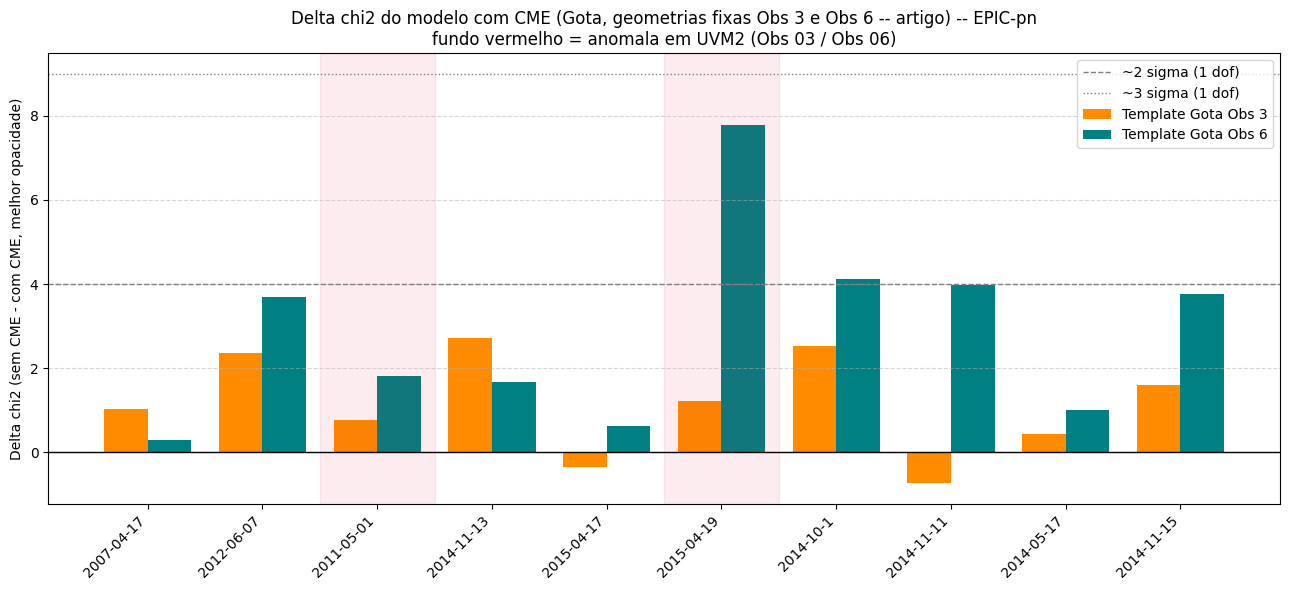

In [20]:
ids_plot_cme = [r['id_obs'] for r in resumo_delta_chi2]
delta_obs03_plot = [r['delta_chi2_obs03'] for r in resumo_delta_chi2]
delta_obs06_plot = [r['delta_chi2_obs06'] for r in resumo_delta_chi2]

x = np.arange(len(ids_plot_cme))
largura = 0.38

plt.figure(figsize=(13, 6))
plt.bar(x - largura/2, delta_obs03_plot, width=largura, color='darkorange', label='Template Gota Obs 3')
plt.bar(x + largura/2, delta_obs06_plot, width=largura, color='teal', label='Template Gota Obs 6')
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.axhline(4, color='gray', linestyle='--', linewidth=1, label='~2 sigma (1 dof)')
plt.axhline(9, color='gray', linestyle=':', linewidth=1, label='~3 sigma (1 dof)')

for xi, id_obs in zip(x, ids_plot_cme):
    if id_obs in ids_anomalos_uv:
        plt.axvspan(xi - 0.5, xi + 0.5, color='crimson', alpha=0.08)

plt.xticks(x, [label_por_obs[i] for i in ids_plot_cme], rotation=45, ha='right')
plt.ylabel('Delta chi2 (sem CME - com CME, melhor opacidade)')
plt.title('Delta chi2 do modelo com CME (Gota, geometrias fixas Obs 3 e Obs 6 -- artigo) -- EPIC-pn\nfundo vermelho = anomala em UVM2 (Obs 03 / Obs 06)')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

output_dir = '03-Products/xray'
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, 'delta_chi2_cme_gota_obs03_obs06_hd189733.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"Figura salva em: {file_path}")
plt.show()


## Teste adicional: CME Cápsula (projeção de disco) para Obs 03

A Gota não deu suporte específico pra Obs 03 (Δχ²=0.76 contra seu próprio template — um dos menores da tabela acima). Mas Obs 03 também foi ajustada com o modelo **Cápsula** (projeção de disco) em UV — a outra geometria publicada no artigo, que não foi testada ainda em raios-X. Testando aqui pra ver se essa forma específica dá algum resultado positivo pra Obs 03.

Parâmetros da tabela do artigo (Cápsula, Obs 3): `raio_cme=174`, `p0x=534, p0y=135, p1x=530, p1y=281`, `velocidade_cme=0.0434 UA/h`, `taxa_escurecimento=44.41` (opacidade ajustada em UV: 0.374, livre aqui). Mesma metodologia da seção anterior — geometria fixa, opacidade em grid 0–1, testado contra as 10 observações (não só Obs 03) pra checar especificidade.

In [21]:
CME_TEMPLATE_OBS03_CAPSULA = {
    'raio_cme': 174,
    'p0x': 534,
    'p0y': 135,
    'p1x': 530,
    'p1y': 281,
    'velocidade_cme': 0.0434,
    'taxa_escurecimento': 44.41,
    'altura_inicial_cme': -1,
    'geometria': GeometriaCME.PROJECAO_DISCO,
    'opacidade_fit_uv': 0.374,
}
# Geometria "Capsula" (projecao de disco) validada por MCMC em UVM2 para Obs 3, publicada no artigo.

resumo_delta_chi2_capsula_obs03 = []

for resultado in resultados_xray:
    id_obs = resultado['id_obs']
    tC = tC_por_obs[id_obs]
    parametros_modelo['tC'] = tC

    t_janela, flux_janela = residuo_na_janela_do_transito(resultado['binned_time'], resultado['binned_flux'], tC)
    _, resid_janela = residuo_na_janela_do_transito(resultado['binned_time'], resultado['residuo'], tC)
    _, erro_janela = residuo_na_janela_do_transito(resultado['binned_time'], resultado['binned_error'], tC)

    chi2_sem_cme = np.sum((resid_janela / erro_janela) ** 2)

    chi2s_com_cme = []
    for opac in OPACIDADES_GRID:
        modelo_cme = modelo_de_transito_eclipse_com_cme(t_janela, parametros_modelo, opac, CME_TEMPLATE_OBS03_CAPSULA)
        chi2 = np.sum(((flux_janela - modelo_cme) / erro_janela) ** 2)
        chi2s_com_cme.append(chi2)

    idx_melhor = int(np.argmin(chi2s_com_cme))
    chi2_com_cme_min = chi2s_com_cme[idx_melhor]
    opacidade_melhor = OPACIDADES_GRID[idx_melhor]
    delta_chi2 = chi2_sem_cme - chi2_com_cme_min

    print(f"  {id_obs} ({label_por_obs[id_obs]}) -- OK")

    resumo_delta_chi2_capsula_obs03.append({
        'id_obs': id_obs,
        'label': label_por_obs[id_obs],
        'chi2_sem_cme': chi2_sem_cme,
        'chi2_com_cme': chi2_com_cme_min,
        'opacidade_melhor': opacidade_melhor,
        'delta_chi2': delta_chi2,
    })

print(f"\n{'ID':<12} {'Data':<12} {'chi2 sem CME':>13} {'chi2 com CME':>13} {'opac.':>7} {'Delta chi2':>11}")
for r in resumo_delta_chi2_capsula_obs03:
    marcador = '  <- anomala em UVM2' if r['id_obs'] in ids_anomalos_uv else ''
    print(f"{r['id_obs']:<12} {r['label']:<12} {r['chi2_sem_cme']:>13.3f} {r['chi2_com_cme']:>13.3f} {r['opacidade_melhor']:>7.2f} {r['delta_chi2']:>11.3f}{marcador}")


  0506070201 (2007-04-17) -- OK
  0690890201 (2012-06-07) -- OK
  0672390201 (2011-05-01) -- OK
  0744981401 (2014-11-13) -- OK
  0744981601 (2015-04-17) -- OK
  0744981701 (2015-04-19) -- OK
  0744980801 (2014-10-1) -- OK
  0744981201 (2014-11-11) -- OK
  0744980601 (2014-05-17) -- OK
  0744980701 (2014-11-15) -- OK

ID           Data          chi2 sem CME  chi2 com CME   opac.  Delta chi2
0506070201   2007-04-17          66.779        68.176    0.00      -1.396
0690890201   2012-06-07          87.951        85.633    0.00       2.318
0672390201   2011-05-01         113.028       113.307    0.00      -0.279  <- anomala em UVM2
0744981401   2014-11-13          81.052        79.832    0.00       1.220
0744981601   2015-04-17          86.389        88.308    0.00      -1.919
0744981701   2015-04-19          89.410        87.750    0.00       1.660  <- anomala em UVM2
0744980801   2014-10-1           99.904       101.415    0.00      -1.511
0744981201   2014-11-11         696.116       70

Figura salva em: 03-Products/xray/delta_chi2_cme_capsula_obs03_hd189733.png


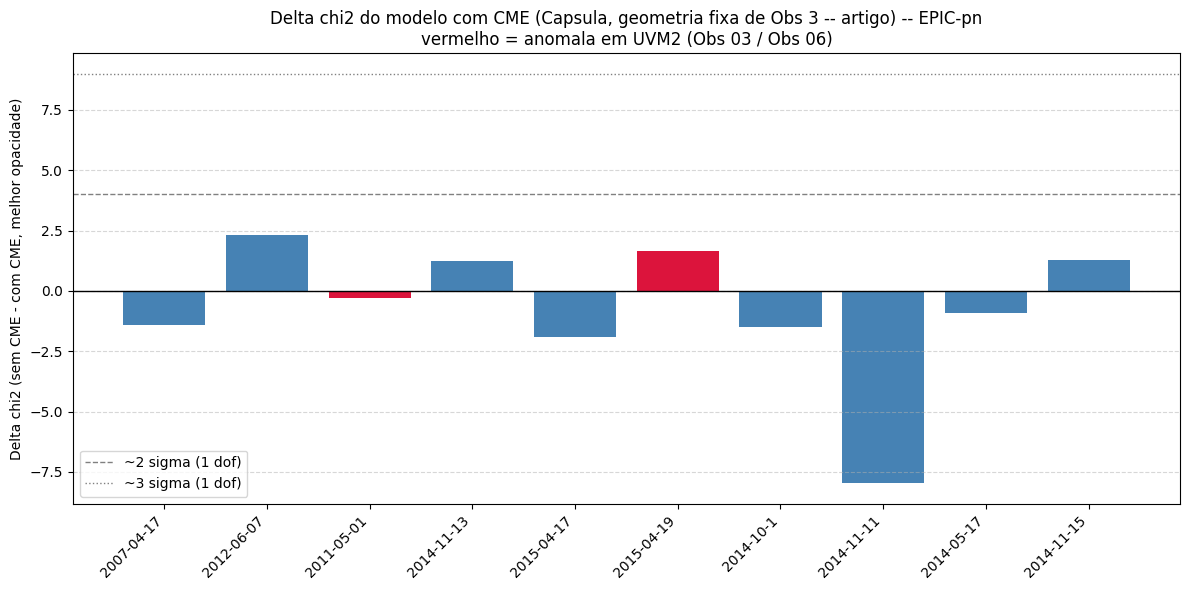

In [22]:
ids_plot_capsula = [r['id_obs'] for r in resumo_delta_chi2_capsula_obs03]
delta_capsula_plot = [r['delta_chi2'] for r in resumo_delta_chi2_capsula_obs03]
cores_plot_capsula = ['crimson' if id_obs in ids_anomalos_uv else 'steelblue' for id_obs in ids_plot_capsula]

plt.figure(figsize=(12, 6))
plt.bar(range(len(ids_plot_capsula)), delta_capsula_plot, color=cores_plot_capsula)
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.axhline(4, color='gray', linestyle='--', linewidth=1, label='~2 sigma (1 dof)')
plt.axhline(9, color='gray', linestyle=':', linewidth=1, label='~3 sigma (1 dof)')
plt.xticks(range(len(ids_plot_capsula)), [label_por_obs[i] for i in ids_plot_capsula], rotation=45, ha='right')
plt.ylabel('Delta chi2 (sem CME - com CME, melhor opacidade)')
plt.title('Delta chi2 do modelo com CME (Capsula, geometria fixa de Obs 3 -- artigo) -- EPIC-pn\nvermelho = anomala em UVM2 (Obs 03 / Obs 06)')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

output_dir = '03-Products/xray'
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, 'delta_chi2_cme_capsula_obs03_hd189733.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"Figura salva em: {file_path}")
plt.show()
